**MobileNetV2+MHA**

Ignoring unknown arguments: ['-f', '/root/.local/share/jupyter/runtime/kernel-12825869-f81e-4814-9924-3983e5267e44.json']
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision disabled. Using float32 for stable training.


# MobileNetV2 + MHA Brain Tumor MRI 44c Training

Dataset slug: fernando2rad/brain-tumor-mri-images-44c
Data directory: /content/brain_tumor_mri_44c
Output directory: /content/mobilenetv2_mha_44c_results
Stage 1 epochs: 25
Stage 2 fine-tune epochs: 35
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
Installing kaggle package...
kaggle.json not found.
Please upload your Kaggle API file now: kaggle.json


Saving kaggle.json to kaggle.json
Kaggle credentials ready: /root/.kaggle/kaggle.json
Extracting: /content/brain_tumor_mri_44c/brain-tumor-mri-images-44c.zip
Dataset download and extraction completed.
Detected image root: /content/brain_tumor_mri_44c | mode=class_root | class/split folders=44 | images=4479


## Dataset Summary

...

## Stage 2: Fine-tuning MobileNetV2 Last Layers

Epoch 1/35
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.9669 - loss: 0.3744 - top3_acc: 0.9984
Epoch 1: val_accuracy improved from None to 0.86830, saving model to /content/mobilenetv2_mha_44c_results/best_mobilenetv2_mha_44c.keras

Epoch 1: finished saving model to /content/mobilenetv2_mha_44c_results/best_mobilenetv2_mha_44c.keras
224/224 ━━━━━━━━━━━━━━━━━━━━ 99s 321ms/step - accuracy: 0.9659 - loss: 0.3853 - top3_acc: 0.9983 - val_accuracy: 0.8683 - val_loss: 0.7426 - val_top3_acc: 0.9554 - learning_rate: 1.0000e-05
Epoch 2/35
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9702 - loss: 0.3797 - top3_acc: 0.9974
Epoch 2: val_accuracy did not improve from 0.86830
224/224 ━━━━━━━━━━━━━━━━━━━━ 49s 219ms/step - accuracy: 0.9673 - loss: 0.3808 - top3_acc: 0.9983 - val_accuracy: 0.8594 - val_loss: 0.8323 - val_top3_acc: 0.9509 - learning_rate: 1.0000e-05
Epoch 3/35
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9705 - loss: 0.3766 - top3_acc: 0.9963
Epoch 3:

### Epoch-wise Training History

,accuracy,loss,top3_acc,val_accuracy,val_loss,val_top3_acc,learning_rate
0,0.251535,3.304662,0.427136,0.524554,2.101223,0.716518,1.000000e-04
1,0.496650,2.132482,0.711614,0.645089,1.609324,0.801339,1.000000e-04
2,0.611669,1.697092,0.804299,0.660714,1.466044,0.852679,1.000000e-04
3,0.668063,1.458356,0.854271,0.712054,1.295091,0.866071,1.000000e-04
4,0.724456,1.258534,0.893076,0.750000,1.191143,0.888393,1.000000e-04
5,0.768286,1.106911,0.919040,0.745536,1.184116,0.886161,1.000000e-04
6,0.796762,0.982642,0.939978,0.794643,1.060039,0.906250,1.000000e-04
7,0.815187,0.919878,0.947515,0.812500,0.974340,0.924107,1.000000e-04
8,0.848688,0.826284,0.958403,0.808036,0.968888,0.921875,1.000000e-04
9,0.864042,0.751314,0.968733,0.821429,0.951726,0.933036,1.000000e-04


## Training Curves

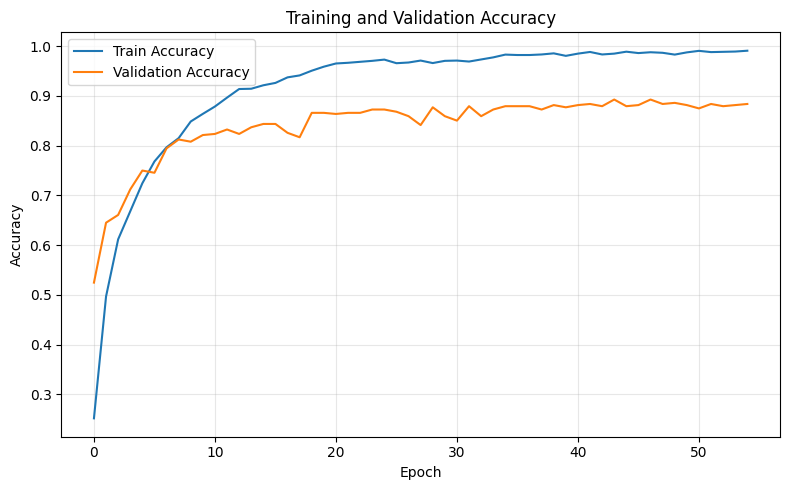

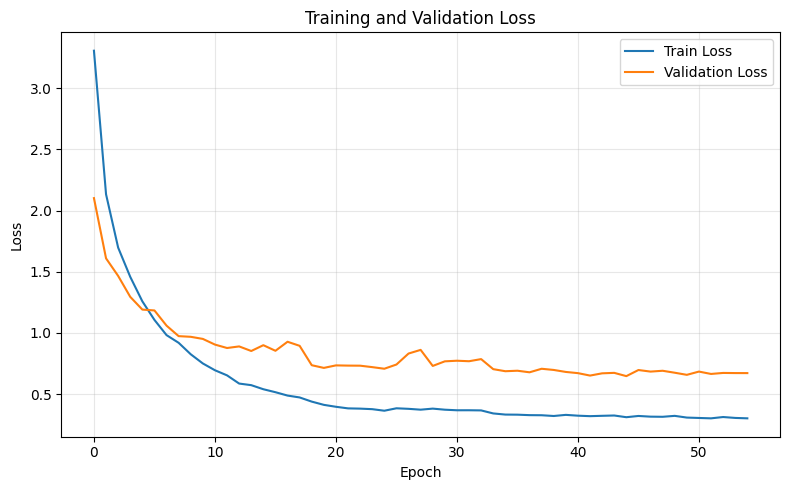

Loading best model: /content/mobilenetv2_mha_44c_results/best_mobilenetv2_mha_44c.keras


# Final Evaluation

224/224 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step


### Train Metrics

,split,loss,keras_accuracy,sklearn_accuracy,top3_accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1
0,train,0.278626,0.995254,0.995254,1.0,0.995397,0.995254,0.995253,0.998236,0.995695,0.996869


### Train Classification Report

,precision,recall,f1-score,support
Astrocitoma T1,1.000000,0.985816,0.992857,141.000000
Astrocitoma T1C+,0.994624,1.000000,0.997305,185.000000
Astrocitoma T2,1.000000,0.992701,0.996337,137.000000
Carcinoma T1,1.000000,1.000000,1.000000,53.000000
Carcinoma T1C+,1.000000,1.000000,1.000000,90.000000
Carcinoma T2,1.000000,1.000000,1.000000,58.000000
Ependimoma T1,1.000000,1.000000,1.000000,36.000000
Ependimoma T1C+,1.000000,1.000000,1.000000,38.000000
Ependimoma T2,1.000000,1.000000,1.000000,46.000000
Ganglioglioma T1,1.000000,1.000000,1.000000,16.000000


## Train Confusion Matrix

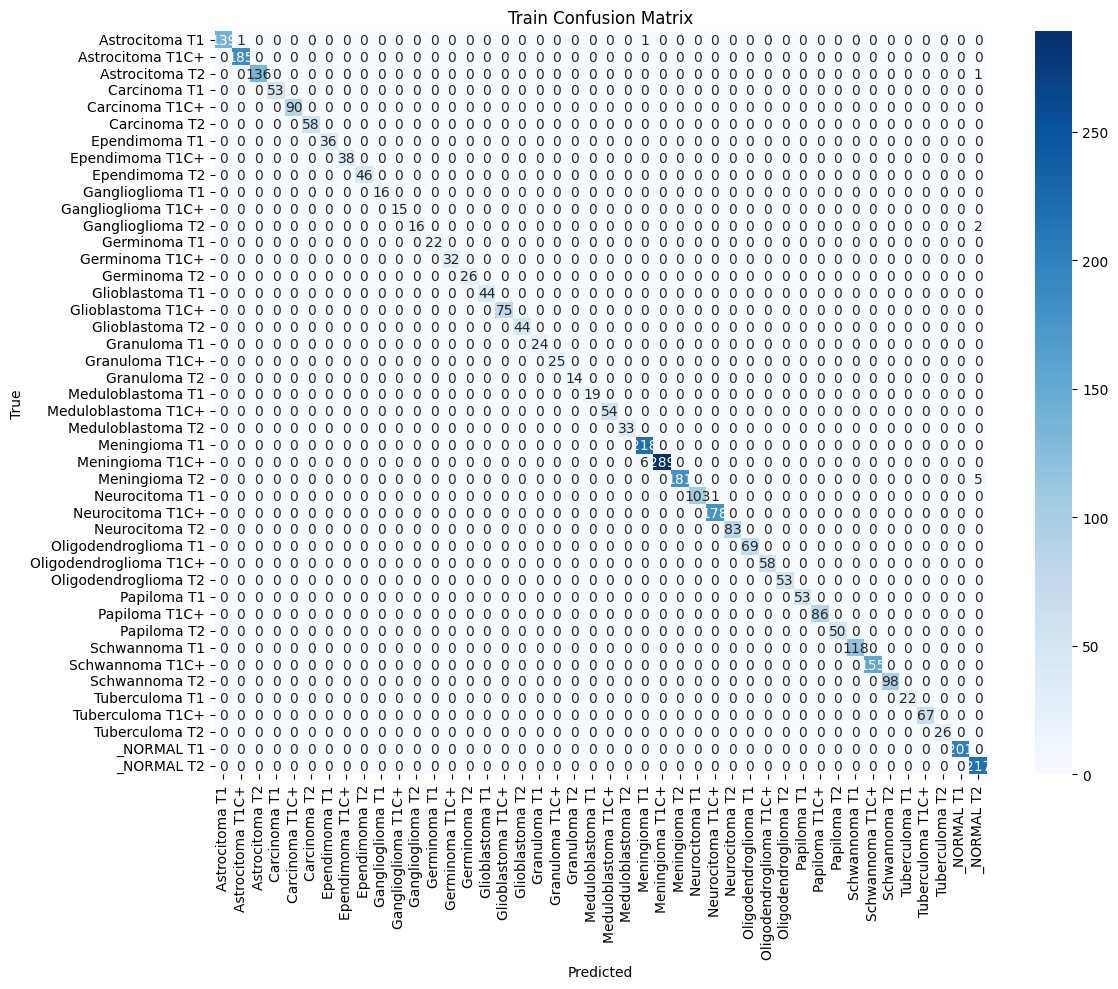

## Train ROC Curve

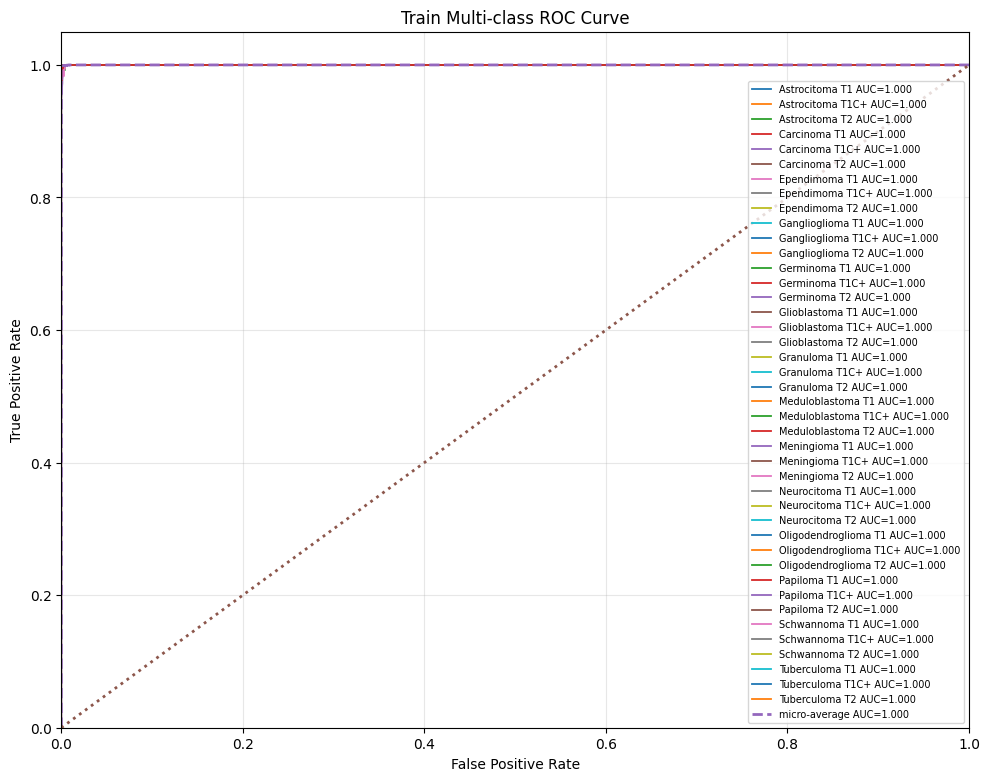

### Train ROC AUC Values

,class,auc
0,Astrocitoma T1,1.000000
1,Astrocitoma T1C+,1.000000
2,Astrocitoma T2,0.999972
3,Carcinoma T1,1.000000
4,Carcinoma T1C+,1.000000
5,Carcinoma T2,1.000000
6,Ependimoma T1,1.000000
7,Ependimoma T1C+,1.000000
8,Ependimoma T2,1.000000
9,Ganglioglioma T1,1.000000


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


### Validation Metrics

,split,loss,keras_accuracy,sklearn_accuracy,top3_accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1
0,validation,0.674545,0.892857,0.892857,0.96875,0.901627,0.892857,0.891314,0.866649,0.867303,0.854011


### Validation Classification Report

,precision,recall,f1-score,support
Astrocitoma T1,1.000000,0.833333,0.909091,18.000000
Astrocitoma T1C+,0.916667,0.916667,0.916667,24.000000
Astrocitoma T2,0.866667,0.764706,0.812500,17.000000
Carcinoma T1,1.000000,0.857143,0.923077,7.000000
Carcinoma T1C+,1.000000,0.818182,0.900000,11.000000
Carcinoma T2,1.000000,1.000000,1.000000,7.000000
Ependimoma T1,1.000000,1.000000,1.000000,4.000000
Ependimoma T1C+,1.000000,0.800000,0.888889,5.000000
Ependimoma T2,0.666667,0.666667,0.666667,6.000000
Ganglioglioma T1,1.000000,0.500000,0.666667,2.000000


## Validation Confusion Matrix

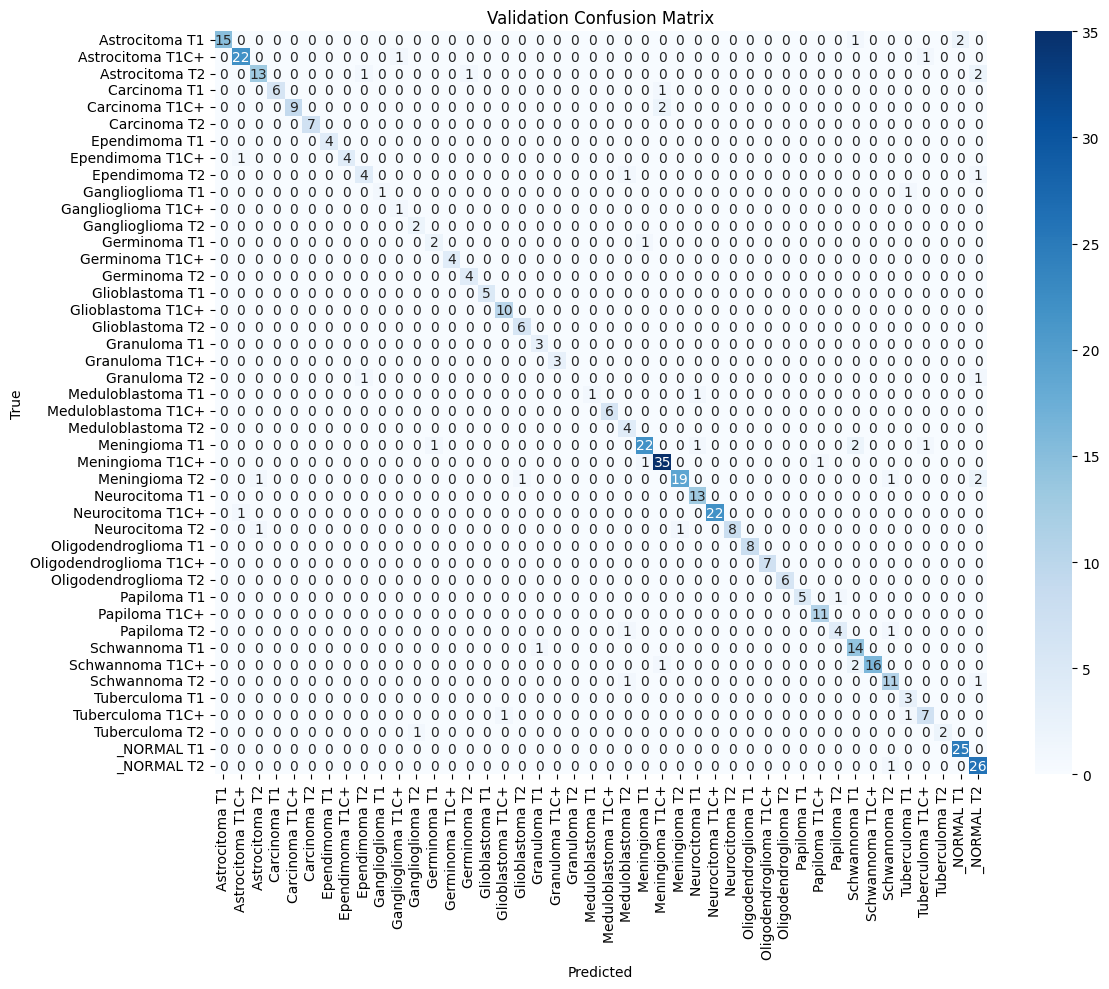

## Validation ROC Curve

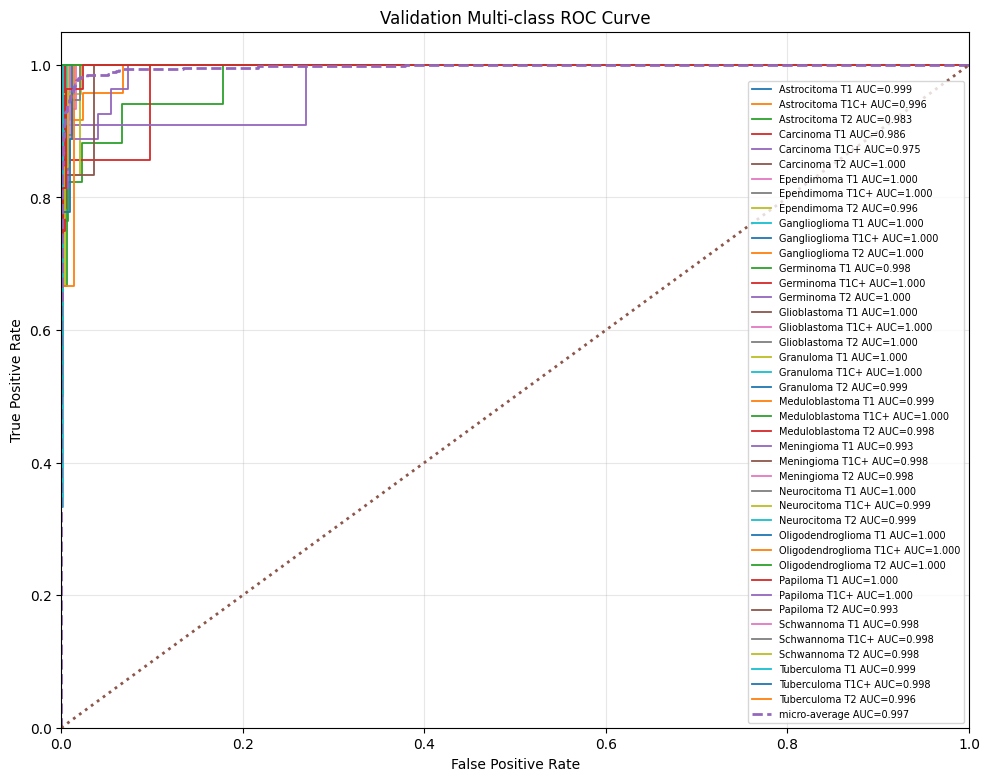

### Validation ROC AUC Values

,class,auc
0,Astrocitoma T1,0.999354
1,Astrocitoma T1C+,0.996167
2,Astrocitoma T2,0.983349
3,Carcinoma T1,0.986071
4,Carcinoma T1C+,0.975452
5,Carcinoma T2,1.000000
6,Ependimoma T1,1.000000
7,Ependimoma T1C+,0.999549
8,Ependimoma T2,0.995852
9,Ganglioglioma T1,1.000000


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step


### Test Metrics

,split,loss,keras_accuracy,sklearn_accuracy,top3_accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1
0,test,0.600439,0.908482,0.908482,0.96875,0.920645,0.908482,0.908474,0.906814,0.883748,0.881202


### Test Classification Report

,precision,recall,f1-score,support
Astrocitoma T1,1.000000,1.000000,1.000000,17.000000
Astrocitoma T1C+,0.952381,0.869565,0.909091,23.000000
Astrocitoma T2,0.888889,0.941176,0.914286,17.000000
Carcinoma T1,0.857143,1.000000,0.923077,6.000000
Carcinoma T1C+,1.000000,0.818182,0.900000,11.000000
Carcinoma T2,1.000000,0.750000,0.857143,8.000000
Ependimoma T1,1.000000,0.600000,0.750000,5.000000
Ependimoma T1C+,1.000000,0.800000,0.888889,5.000000
Ependimoma T2,0.666667,0.800000,0.727273,5.000000
Ganglioglioma T1,1.000000,1.000000,1.000000,2.000000


## Test Confusion Matrix

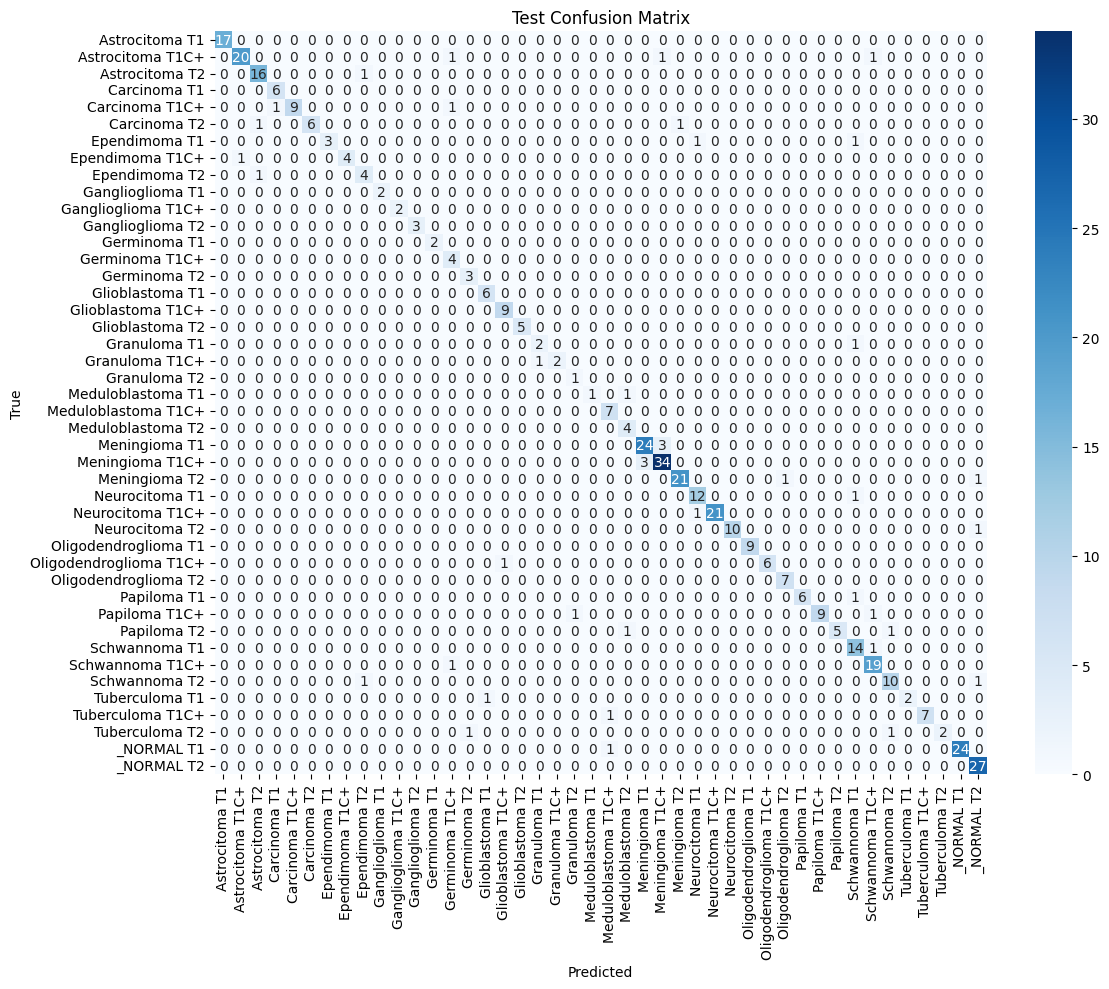

## Test ROC Curve

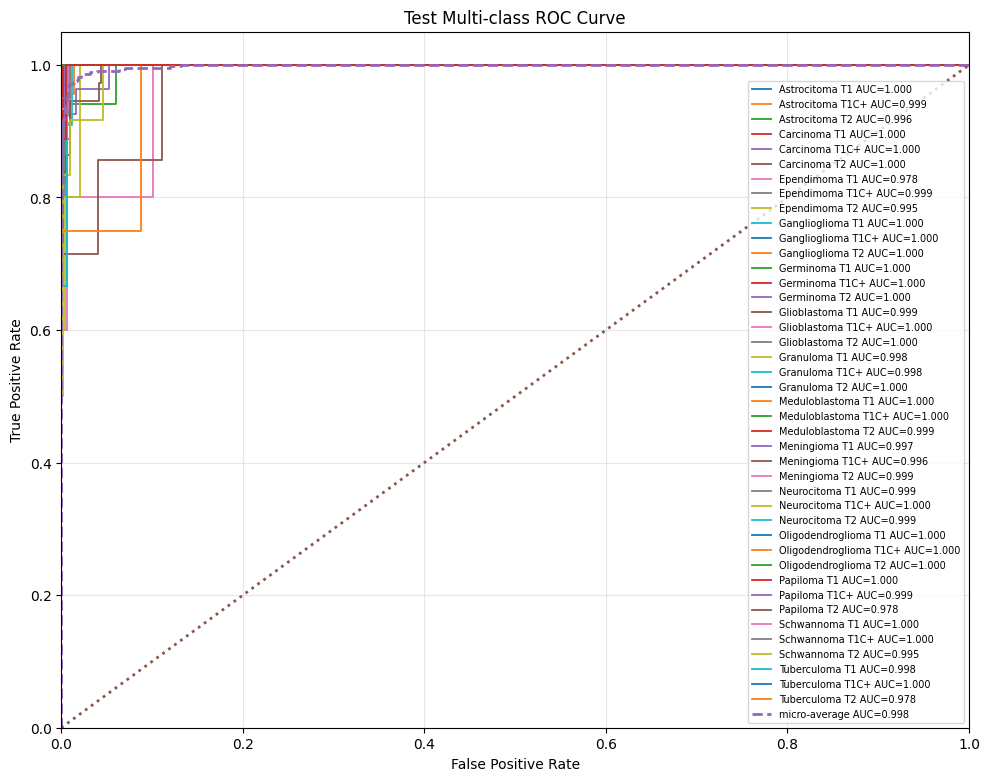

### Test ROC AUC Values

,class,auc
0,Astrocitoma T1,1.000000
1,Astrocitoma T1C+,0.998568
2,Astrocitoma T2,0.995906
3,Carcinoma T1,1.000000
4,Carcinoma T1C+,1.000000
5,Carcinoma T2,1.000000
6,Ependimoma T1,0.978330
7,Ependimoma T1C+,0.999097
8,Ependimoma T2,0.995034
9,Ganglioglioma T1,1.000000


### All Metrics Summary

,split,loss,keras_accuracy,sklearn_accuracy,top3_accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1
0,train,0.278626,0.995254,0.995254,1.00000,0.995397,0.995254,0.995253,0.998236,0.995695,0.996869
1,validation,0.674545,0.892857,0.892857,0.96875,0.901627,0.892857,0.891314,0.866649,0.867303,0.854011
2,test,0.600439,0.908482,0.908482,0.96875,0.920645,0.908482,0.908474,0.906814,0.883748,0.881202


## Completed

Results displayed inline and saved in: /content/mobilenetv2_mha_44c_results
Important files:
 - all_metrics_summary.csv
 - train_confusion_matrix.png / validation_confusion_matrix.png / test_confusion_matrix.png
 - train_roc_curve.png / validation_roc_curve.png / test_roc_curve.png
 - train_roc_auc.csv / validation_roc_auc.csv / test_roc_auc.csv
 - accuracy_curve.png
 - loss_curve.png
 - best_mobilenetv2_mha_44c.keras


In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
MobileNetV2 + Multi-Head Attention full pipeline for Brain Tumor MRI 44c dataset.
Dataset: https://www.kaggle.com/datasets/fernando2rad/brain-tumor-mri-images-44c
Includes Kaggle dataset download with kaggle.json upload option in Colab.
Default dataset path: /content/brain_tumor_mri_44c

Includes:
- Robust dataset-root detection
- Stratified train/validation/test split
- MobileNetV2 transfer learning + Multi-Head Attention block
- Stage 1: classifier/MHA head training
- Stage 2: fine-tuning MobileNetV2 last layers
- Train/validation/test metrics
- Train/validation/test classification reports
- Train/validation/test confusion matrices
- Train/validation/test ROC curves and AUC values
- Accuracy/loss curves
- All outputs saved to output_dir and shown inline in Colab

Colab run:
!python /content/mobilenetv2_mha_44c_with_download_full_metrics.py

Optional:
!python /content/mobilenetv2_mha_44c_with_download_full_metrics.py --epochs 25 --finetune_epochs 35 --batch_size 16
"""

import os
import sys
import json
import shutil
import zipfile
import argparse
import subprocess
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger,
    TerminateOnNaN,
)

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from IPython.display import display, Markdown
    IN_NOTEBOOK = True
except Exception:
    IN_NOTEBOOK = False

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
BAD_DIR_NAMES = {"__MACOSX", ".ipynb_checkpoints"}


def md(text):
    if IN_NOTEBOOK:
        display(Markdown(text))
    else:
        print(text.replace("#", ""))


def show_df(title, df, max_rows=100):
    md(f"### {title}")
    if IN_NOTEBOOK:
        display(df.head(max_rows))
    else:
        print(df.head(max_rows).to_string(index=False))


def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)


def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)


def setup_gpu(disable_mixed_precision=True):
    gpus = tf.config.list_physical_devices("GPU")
    print("GPUs found:", gpus)
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception:
            pass

    if disable_mixed_precision:
        tf.keras.mixed_precision.set_global_policy("float32")
        print("Mixed precision disabled. Using float32 for stable training.")
    else:
        try:
            tf.keras.mixed_precision.set_global_policy("mixed_float16")
            print("Mixed precision enabled.")
        except Exception as e:
            print("Mixed precision not enabled:", e)



def dataset_already_has_images(data_dir):
    data_dir = Path(data_dir)
    if not data_dir.exists():
        return False
    count = 0
    for p in data_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
            count += 1
            if count > 20:
                return True
    return count > 0


def setup_kaggle_credentials():
    kaggle_dir = Path.home() / ".kaggle"
    kaggle_json = kaggle_dir / "kaggle.json"
    ensure_dir(kaggle_dir)

    if kaggle_json.exists():
        os.chmod(kaggle_json, 0o600)
        print(f"Kaggle credentials ready: {kaggle_json}")
        return True

    content_json = Path("/content/kaggle.json")
    if content_json.exists():
        shutil.copy(str(content_json), str(kaggle_json))
        os.chmod(kaggle_json, 0o600)
        print(f"Kaggle credentials copied from {content_json}")
        return True

    username = os.environ.get("KAGGLE_USERNAME")
    key = os.environ.get("KAGGLE_KEY")
    if username and key:
        with open(kaggle_json, "w", encoding="utf-8") as f:
            json.dump({"username": username, "key": key}, f)
        os.chmod(kaggle_json, 0o600)
        print("Kaggle credentials created from environment variables.")
        return True

    try:
        import google.colab  # type: ignore
        from google.colab import files  # type: ignore
        print("kaggle.json not found.")
        print("Please upload your Kaggle API file now: kaggle.json")
        uploaded = files.upload()
        if "kaggle.json" not in uploaded:
            print("Uploaded files:", list(uploaded.keys()))
            raise RuntimeError("Please upload exactly kaggle.json from Kaggle Account > Settings > Create New Token.")
        shutil.move("kaggle.json", str(kaggle_json))
        os.chmod(kaggle_json, 0o600)
        print(f"Kaggle credentials ready: {kaggle_json}")
        return True
    except ImportError:
        return False


def install_kaggle_if_needed():
    try:
        import kaggle  # noqa: F401
    except Exception:
        print("Installing kaggle package...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])


def download_dataset(dataset_slug, data_dir, force_download=False, skip_download=False):
    ensure_dir(data_dir)
    if skip_download:
        print("skip_download=True. Using existing dataset folder:", data_dir)
        return
    if dataset_already_has_images(data_dir) and not force_download:
        print(f"Existing dataset/images found in: {data_dir}. Skipping download.")
        return

    install_kaggle_if_needed()
    if not setup_kaggle_credentials():
        raise RuntimeError(
            "Kaggle credentials not found. Upload kaggle.json to /content/kaggle.json "
            "or set KAGGLE_USERNAME and KAGGLE_KEY environment variables."
        )

    cmd = ["kaggle", "datasets", "download", "-d", dataset_slug, "-p", data_dir, "--force"]
    print("Downloading dataset:", " ".join(cmd))
    subprocess.check_call(cmd)

    zip_files = list(Path(data_dir).glob("*.zip"))
    if not zip_files:
        raise RuntimeError(f"Dataset zip not found in {data_dir}")

    for zf in zip_files:
        print("Extracting:", zf)
        with zipfile.ZipFile(zf, "r") as zip_ref:
            zip_ref.extractall(data_dir)
    print("Dataset download and extraction completed.")


def count_images_inside(folder):
    folder = Path(folder)
    return sum(1 for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)


def debug_tree(data_dir, max_depth=5, max_items=160):
    print("\nDataset folder preview:")
    data_dir = Path(data_dir)
    shown = 0
    for root, dirs, files in os.walk(data_dir):
        dirs[:] = [d for d in dirs if d not in BAD_DIR_NAMES and not d.startswith(".")]
        depth = len(Path(root).relative_to(data_dir).parts)
        if depth > max_depth:
            dirs[:] = []
            continue
        indent = "  " * depth
        img_files = [f for f in files if Path(f).suffix.lower() in IMAGE_EXTENSIONS]
        print(f"{indent}{Path(root).name}/ dirs={len(dirs)} images_here={len(img_files)} total_images={count_images_inside(root)}")
        shown += 1
        if shown >= max_items:
            print("... preview truncated ...")
            break


def is_split_name(name):
    return name.lower().strip() in {"train", "training", "valid", "validation", "val", "test", "testing"}


def find_image_root(data_dir):
    data_dir = Path(data_dir)
    if not data_dir.exists():
        raise RuntimeError(f"Data directory does not exist: {data_dir}")

    candidates = []
    for root, dirs, files in os.walk(data_dir):
        rootp = Path(root)
        dirs[:] = [d for d in dirs if d not in BAD_DIR_NAMES and not d.startswith(".")]
        if len(rootp.relative_to(data_dir).parts) > 8:
            dirs[:] = []
            continue
        child_dirs = [rootp / d for d in dirs]
        if len(child_dirs) < 2:
            continue

        direct_class_dirs = []
        split_dirs = []
        total_child_images = 0
        for cd in child_dirs:
            n = count_images_inside(cd)
            total_child_images += n
            try:
                direct_here = sum(1 for p in cd.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
            except Exception:
                direct_here = 0
            if direct_here > 0:
                direct_class_dirs.append(cd)
            if is_split_name(cd.name) and n > 0:
                split_dirs.append(cd)

        if len(direct_class_dirs) >= 2:
            candidates.append((rootp, len(direct_class_dirs), total_child_images, "class_root"))

        if len(split_dirs) >= 1:
            split_class_count = 0
            for sd in split_dirs:
                for c in sd.iterdir():
                    if c.is_dir() and count_images_inside(c) > 0:
                        split_class_count += 1
            if split_class_count >= 2:
                candidates.append((rootp, split_class_count, total_child_images, "split_root"))

    if not candidates:
        debug_tree(data_dir)
        label_parents = {}
        for p in data_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
                label_parents.setdefault(str(p.parent), 0)
                label_parents[str(p.parent)] += 1
        if len(label_parents) >= 2:
            common = os.path.commonpath(list(label_parents.keys()))
            print(f"Fallback image root detected: {common}")
            return Path(common)
        raise RuntimeError(f"Could not detect class-folder image root inside {data_dir}. Check extraction structure above.")

    candidates = sorted(candidates, key=lambda x: (x[2], x[1]), reverse=True)
    root, nclasses, nimgs, mode = candidates[0]
    print(f"Detected image root: {root} | mode={mode} | class/split folders={nclasses} | images={nimgs}")
    return root


def make_dataframe(image_root):
    image_root = Path(image_root)
    records = []

    split_dirs = [d for d in image_root.iterdir() if d.is_dir() and is_split_name(d.name)]
    if split_dirs:
        for split_dir in split_dirs:
            split_name = split_dir.name.lower()
            if split_name in {"valid", "validation", "val"}:
                split_name = "val"
            elif split_name in {"train", "training"}:
                split_name = "train"
            elif split_name in {"test", "testing"}:
                split_name = "test"
            for class_dir in split_dir.iterdir():
                if not class_dir.is_dir():
                    continue
                for p in class_dir.rglob("*"):
                    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
                        records.append({"filepath": str(p), "label": class_dir.name, "given_split": split_name})
    else:
        for class_dir in image_root.iterdir():
            if not class_dir.is_dir() or class_dir.name.startswith("."):
                continue
            for p in class_dir.rglob("*"):
                if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
                    records.append({"filepath": str(p), "label": class_dir.name, "given_split": "none"})

    df = pd.DataFrame(records)
    if df.empty:
        debug_tree(image_root)
        raise RuntimeError(f"No images found under detected image root: {image_root}")

    before = len(df)
    df = df.drop_duplicates(subset=["filepath"]).reset_index(drop=True)

    class_counts = df["label"].value_counts().sort_index().reset_index()
    class_counts.columns = ["class", "count"]
    md("## Dataset Summary")
    print(f"Total images found: {len(df)} | duplicates removed: {before - len(df)}")
    print(f"Detected classes: {df['label'].nunique()}")
    show_df("Class Distribution", class_counts, max_rows=100)
    return df


def stratified_split(df, seed=42):
    if set(df["given_split"].unique()) & {"train", "val", "test"}:
        if {"train", "val", "test"}.issubset(set(df["given_split"].unique())):
            print("Using existing train/val/test split from dataset folders.")
            return df[df.given_split == "train"].copy(), df[df.given_split == "val"].copy(), df[df.given_split == "test"].copy()
        print("Partial split folders found; creating fresh stratified 80/10/10 split.")

    train_df, temp_df = train_test_split(
        df,
        test_size=0.20,
        stratify=df["label"],
        random_state=seed,
        shuffle=True,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df["label"],
        random_state=seed,
        shuffle=True,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def save_dataset_split_tables(train_df, val_df, test_df, out_dir):
    train_df.to_csv(Path(out_dir) / "train_split.csv", index=False)
    val_df.to_csv(Path(out_dir) / "validation_split.csv", index=False)
    test_df.to_csv(Path(out_dir) / "test_split.csv", index=False)

    all_labels = sorted(set(train_df.label) | set(val_df.label) | set(test_df.label))
    rows = []
    for label in all_labels:
        rows.append({
            "class": label,
            "train": int((train_df.label == label).sum()),
            "validation": int((val_df.label == label).sum()),
            "test": int((test_df.label == label).sum()),
            "total": int((train_df.label == label).sum() + (val_df.label == label).sum() + (test_df.label == label).sum()),
        })
    split_df = pd.DataFrame(rows)
    split_df.to_csv(Path(out_dir) / "dataset_split_distribution.csv", index=False)
    show_df("Train / Validation / Test Split Distribution", split_df, max_rows=100)


def build_generators(train_df, val_df, test_df, image_size, batch_size, seed):
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=12,
        width_shift_range=0.06,
        height_shift_range=0.06,
        zoom_range=0.12,
        shear_range=0.03,
        horizontal_flip=True,
        fill_mode="nearest",
    )
    eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    common = dict(
        x_col="filepath",
        y_col="label",
        target_size=(image_size, image_size),
        color_mode="rgb",
        class_mode="categorical",
        batch_size=batch_size,
        validate_filenames=True,
    )

    train_gen = train_datagen.flow_from_dataframe(train_df, shuffle=True, seed=seed, **common)
    train_eval_gen = eval_datagen.flow_from_dataframe(train_df, shuffle=False, **common)
    val_gen = eval_datagen.flow_from_dataframe(val_df, shuffle=False, **common)
    test_gen = eval_datagen.flow_from_dataframe(test_df, shuffle=False, **common)
    return train_gen, train_eval_gen, val_gen, test_gen


def build_mobilenetv2_mha_model(
    num_classes,
    image_size=224,
    dropout=0.35,
    lr=1e-4,
    train_base=False,
    mha_heads=4,
    mha_key_dim=64,
):
    base = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(image_size, image_size, 3),
        alpha=1.0,
    )
    base.trainable = train_base

    inputs = layers.Input(shape=(image_size, image_size, 3), name="input_image")
    x = base(inputs, training=False)

    # MobileNetV2 output: 7x7x1280 at 224x224 input.
    # Convert spatial feature map into tokens for multi-head self-attention.
    x = layers.Reshape((-1, x.shape[-1]), name="spatial_tokens")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="tokens_ln")(x)

    attn = layers.MultiHeadAttention(
        num_heads=mha_heads,
        key_dim=mha_key_dim,
        dropout=0.10,
        name="multi_head_self_attention",
    )(x, x)
    x = layers.Add(name="attention_residual")([x, attn])
    x = layers.LayerNormalization(epsilon=1e-6, name="post_attention_ln")(x)

    ff = layers.Dense(512, activation="gelu", kernel_regularizer=regularizers.l2(1e-4), name="token_ffn_dense1")(x)
    ff = layers.Dropout(dropout, name="token_ffn_dropout")(ff)
    ff = layers.Dense(x.shape[-1], kernel_regularizer=regularizers.l2(1e-4), name="token_ffn_dense2")(ff)
    x = layers.Add(name="ffn_residual")([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6, name="post_ffn_ln")(x)

    avg_pool = layers.GlobalAveragePooling1D(name="token_average_pooling")(x)
    max_pool = layers.GlobalMaxPooling1D(name="token_max_pooling")(x)
    x = layers.Concatenate(name="avg_max_token_features")([avg_pool, max_pool])

    x = layers.BatchNormalization(name="head_bn1")(x)
    x = layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(1e-4), name="head_dense_512")(x)
    x = layers.BatchNormalization(name="head_bn2")(x)
    x = layers.Dropout(dropout, name="head_dropout1")(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4), name="head_dense_256")(x)
    x = layers.BatchNormalization(name="head_bn3")(x)
    x = layers.Dropout(dropout / 2.0, name="head_dropout2")(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32", name="classifier")(x)

    model = models.Model(inputs, outputs, name="MobileNetV2_MHA_BrainTumor_44c")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        loss="categorical_crossentropy",
        metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc")],
    )
    return model, base


def get_callbacks(out_dir, filename="best_mobilenetv2_mha_44c.keras", patience_es=8, patience_lr=4):
    return [
        ModelCheckpoint(filepath=str(Path(out_dir) / filename), monitor="val_accuracy", save_best_only=True, mode="max", verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=patience_lr, min_lr=1e-7, verbose=1),
        EarlyStopping(monitor="val_loss", patience=patience_es, restore_best_weights=True, verbose=1),
        TerminateOnNaN(),
        CSVLogger(str(Path(out_dir) / "training_log.csv"), append=True),
    ]


def fine_tune_model(model, base_model, lr=1e-5, unfreeze_last=35):
    base_model.trainable = True
    for layer in base_model.layers[:-unfreeze_last]:
        layer.trainable = False
    for layer in base_model.layers[-unfreeze_last:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        loss="categorical_crossentropy",
        metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc")],
    )
    return model


def compute_class_weights_from_generator(train_gen):
    y = train_gen.classes
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return {int(c): float(w) for c, w in zip(classes, weights)}


def merge_histories(*histories):
    merged = {}
    for h in histories:
        if h is None:
            continue
        for k, v in h.history.items():
            merged.setdefault(k, []).extend(v)
    return merged


def plot_curves(history, out_dir, show_inline=True):
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(Path(out_dir) / "history.csv", index=False)
    show_df("Epoch-wise Training History", hist_df, max_rows=200)

    md("## Training Curves")
    plt.figure(figsize=(8, 5))
    if "accuracy" in history:
        plt.plot(history["accuracy"], label="Train Accuracy")
    if "val_accuracy" in history:
        plt.plot(history["val_accuracy"], label="Validation Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(Path(out_dir) / "accuracy_curve.png", dpi=300)
    if show_inline:
        plt.show()
    else:
        plt.close()

    plt.figure(figsize=(8, 5))
    if "loss" in history:
        plt.plot(history["loss"], label="Train Loss")
    if "val_loss" in history:
        plt.plot(history["val_loss"], label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(Path(out_dir) / "loss_curve.png", dpi=300)
    if show_inline:
        plt.show()
    else:
        plt.close()


def evaluate_and_save(model, gen, split_name, out_dir, class_names, show_inline=True):
    gen.reset()
    probs = model.predict(gen, verbose=1)
    y_true = gen.classes
    y_pred = np.argmax(probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    loss, keras_acc, top3 = model.evaluate(gen, verbose=0)

    metrics = {
        "split": split_name,
        "loss": float(loss),
        "keras_accuracy": float(keras_acc),
        "sklearn_accuracy": float(acc),
        "top3_accuracy": float(top3),
        "weighted_precision": float(precision),
        "weighted_recall": float(recall),
        "weighted_f1": float(f1),
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
    }
    metrics_df = pd.DataFrame([metrics])
    metrics_df.to_csv(Path(out_dir) / f"{split_name}_metrics.csv", index=False)
    show_df(f"{split_name.capitalize()} Metrics", metrics_df, max_rows=5)

    report_dict = classification_report(y_true, y_pred, target_names=class_names, zero_division=0, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()
    report_df.to_csv(Path(out_dir) / f"{split_name}_classification_report.csv")
    with open(Path(out_dir) / f"{split_name}_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(classification_report(y_true, y_pred, target_names=class_names, zero_division=0, digits=4))
    show_df(f"{split_name.capitalize()} Classification Report", report_df, max_rows=100)

    cm = confusion_matrix(y_true, y_pred)
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(Path(out_dir) / f"{split_name}_confusion_matrix.csv")

    md(f"## {split_name.capitalize()} Confusion Matrix")
    plt.figure(figsize=(12, 10))
    if sns is not None:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    else:
        plt.imshow(cm)
        plt.colorbar()
        plt.xticks(range(len(class_names)), class_names, rotation=90)
        plt.yticks(range(len(class_names)), class_names)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.title(f"{split_name.capitalize()} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(Path(out_dir) / f"{split_name}_confusion_matrix.png", dpi=300)
    if show_inline:
        plt.show()
    else:
        plt.close()

    np.save(Path(out_dir) / f"{split_name}_probabilities.npy", probs)
    np.save(Path(out_dir) / f"{split_name}_true_labels.npy", y_true)
    np.save(Path(out_dir) / f"{split_name}_pred_labels.npy", y_pred)
    return metrics, y_true, y_pred, probs


def plot_multiclass_roc(y_true, probs, class_names, out_dir, split_name="test", show_inline=True):
    n_classes = len(class_names)
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    roc_rows = []

    md(f"## {split_name.capitalize()} ROC Curve")
    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        if np.sum(y_bin[:, i]) == 0:
            continue
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], probs[:, i])
        auc_i = auc(fpr_i, tpr_i)
        roc_rows.append({"class": class_names[i], "auc": auc_i})
        plt.plot(fpr_i, tpr_i, lw=1.3, label=f"{class_names[i]} AUC={auc_i:.3f}")

    fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), probs.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    roc_rows.append({"class": "micro_average", "auc": auc_micro})
    plt.plot(fpr_micro, tpr_micro, linestyle="--", lw=2, label=f"micro-average AUC={auc_micro:.3f}")

    plt.plot([0, 1], [0, 1], linestyle=":", lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{split_name.capitalize()} Multi-class ROC Curve")
    plt.legend(loc="lower right", fontsize=7)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(Path(out_dir) / f"{split_name}_roc_curve.png", dpi=300)
    if show_inline:
        plt.show()
    else:
        plt.close()

    roc_df = pd.DataFrame(roc_rows)
    roc_df.to_csv(Path(out_dir) / f"{split_name}_roc_auc.csv", index=False)
    show_df(f"{split_name.capitalize()} ROC AUC Values", roc_df, max_rows=100)


def zip_results(out_dir):
    try:
        zip_path = shutil.make_archive(str(Path(out_dir)), "zip", out_dir)
        print("Backup ZIP saved:", zip_path)
    except Exception as e:
        print("ZIP creation skipped:", e)


def main(args):
    set_seed(args.seed)
    setup_gpu(disable_mixed_precision=not args.enable_mixed_precision)
    ensure_dir(args.output_dir)

    md("# MobileNetV2 + MHA Brain Tumor MRI 44c Training")
    print("Dataset slug:", args.dataset_slug)
    print("Data directory:", args.data_dir)
    print("Output directory:", args.output_dir)
    print("Stage 1 epochs:", args.epochs)
    print("Stage 2 fine-tune epochs:", args.finetune_epochs)

    download_dataset(args.dataset_slug, args.data_dir, force_download=args.force_download, skip_download=args.skip_download)
    image_root = find_image_root(args.data_dir)
    df = make_dataframe(image_root)

    train_df, val_df, test_df = stratified_split(df, seed=args.seed)
    print(f"Split sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
    save_dataset_split_tables(train_df, val_df, test_df, args.output_dir)

    train_gen, train_eval_gen, val_gen, test_gen = build_generators(
        train_df, val_df, test_df, args.image_size, args.batch_size, args.seed
    )
    class_indices = train_gen.class_indices
    class_names = [None] * len(class_indices)
    for name, idx in class_indices.items():
        class_names[idx] = name
    with open(Path(args.output_dir) / "class_indices.json", "w", encoding="utf-8") as f:
        json.dump(class_indices, f, indent=2)

    class_weights = compute_class_weights_from_generator(train_gen) if args.use_class_weights else None
    if class_weights is not None:
        with open(Path(args.output_dir) / "class_weights.json", "w", encoding="utf-8") as f:
            json.dump(class_weights, f, indent=2)
        print("Class weights enabled for imbalanced 44-class training.")

    model, base_model = build_mobilenetv2_mha_model(
        num_classes=len(class_names),
        image_size=args.image_size,
        dropout=args.dropout,
        lr=args.lr,
        train_base=False,
        mha_heads=args.mha_heads,
        mha_key_dim=args.mha_key_dim,
    )
    model.summary()

    best_model_name = "best_mobilenetv2_mha_44c.keras"

    md("## Stage 1: Training MobileNetV2 + MHA Classifier Head")
    h1 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=args.epochs,
        callbacks=get_callbacks(args.output_dir, best_model_name, patience_es=args.patience_stage1, patience_lr=4),
        class_weight=class_weights,
        verbose=1,
    )

    h2 = None
    if args.finetune_epochs > 0:
        md("## Stage 2: Fine-tuning MobileNetV2 Last Layers")
        model = fine_tune_model(model, base_model, lr=args.finetune_lr, unfreeze_last=args.unfreeze_last)
        h2 = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=args.finetune_epochs,
            callbacks=get_callbacks(args.output_dir, best_model_name, patience_es=args.patience_stage2, patience_lr=4),
            class_weight=class_weights,
            verbose=1,
        )

    history = merge_histories(h1, h2)
    plot_curves(history, args.output_dir, show_inline=not args.no_inline)

    best_path = Path(args.output_dir) / best_model_name
    if best_path.exists():
        print(f"Loading best model: {best_path}")
        model = tf.keras.models.load_model(best_path)

    md("# Final Evaluation")
    all_metrics = []
    for split_name, gen in [("train", train_eval_gen), ("validation", val_gen), ("test", test_gen)]:
        metrics, y_true, y_pred, probs = evaluate_and_save(
            model, gen, split_name, args.output_dir, class_names, show_inline=not args.no_inline
        )
        all_metrics.append(metrics)
        plot_multiclass_roc(
            y_true, probs, class_names, args.output_dir, split_name=split_name, show_inline=not args.no_inline
        )

    summary_df = pd.DataFrame(all_metrics)
    summary_df.to_csv(Path(args.output_dir) / "all_metrics_summary.csv", index=False)
    show_df("All Metrics Summary", summary_df, max_rows=10)

    model.save(Path(args.output_dir) / "final_mobilenetv2_mha_44c.keras")
    if args.make_zip:
        zip_results(args.output_dir)

    md("## Completed")
    print("Results displayed inline and saved in:", args.output_dir)
    print("Important files:")
    print(" - all_metrics_summary.csv")
    print(" - train_confusion_matrix.png / validation_confusion_matrix.png / test_confusion_matrix.png")
    print(" - train_roc_curve.png / validation_roc_curve.png / test_roc_curve.png")
    print(" - train_roc_auc.csv / validation_roc_auc.csv / test_roc_auc.csv")
    print(" - accuracy_curve.png")
    print(" - loss_curve.png")
    print(" - best_mobilenetv2_mha_44c.keras")


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="MobileNetV2 + MHA pipeline for Brain Tumor MRI 44c with full metrics")
    parser.add_argument("--dataset_slug", type=str, default="fernando2rad/brain-tumor-mri-images-44c")
    parser.add_argument("--data_dir", type=str, default="/content/brain_tumor_mri_44c")
    parser.add_argument("--skip_download", action="store_true", help="Skip Kaggle download and use existing dataset folder.")
    parser.add_argument("--force_download", action="store_true", help="Force re-download dataset even if images already exist.")
    parser.add_argument("--output_dir", type=str, default="/content/mobilenetv2_mha_44c_results")
    parser.add_argument("--image_size", type=int, default=224)
    parser.add_argument("--batch_size", type=int, default=16)
    parser.add_argument("--epochs", type=int, default=25)
    parser.add_argument("--finetune_epochs", type=int, default=35)
    parser.add_argument("--lr", type=float, default=1e-4)
    parser.add_argument("--finetune_lr", type=float, default=1e-5)
    parser.add_argument("--dropout", type=float, default=0.35)
    parser.add_argument("--unfreeze_last", type=int, default=35)
    parser.add_argument("--mha_heads", type=int, default=4)
    parser.add_argument("--mha_key_dim", type=int, default=64)
    parser.add_argument("--patience_stage1", type=int, default=8)
    parser.add_argument("--patience_stage2", type=int, default=10)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--use_class_weights", action="store_true", help="Use class weights for imbalanced classes.")
    parser.add_argument("--enable_mixed_precision", action="store_true", help="Enable mixed precision. Default is OFF for stability.")
    parser.add_argument("--no_inline", action="store_true", help="Disable inline plots/tables, only save files")
    parser.add_argument("--make_zip", action="store_true", help="Also create ZIP backup of result folder")

    args, unknown = parser.parse_known_args()
    if unknown:
        print("Ignoring unknown arguments:", unknown)
    main(args)


In [3]:
# ZIP + DOWNLOAD IN SINGLE CELL

!zip -r /content/mobilenetv2_mha_44c_results.zip /content/mobilenetv2_mha_44c_results

from google.colab import files
files.download('/content/mobilenetv2_mha_44c_results.zip')

  adding: content/mobilenetv2_mha_44c_results/ (stored 0%)
  adding: content/mobilenetv2_mha_44c_results/best_mobilenetv2_mha_44c.keras (deflated 9%)
  adding: content/mobilenetv2_mha_44c_results/test_split.csv (deflated 80%)
  adding: content/mobilenetv2_mha_44c_results/test_pred_labels.npy (deflated 81%)
  adding: content/mobilenetv2_mha_44c_results/test_roc_auc.csv (deflated 62%)
  adding: content/mobilenetv2_mha_44c_results/train_split.csv (deflated 82%)
  adding: content/mobilenetv2_mha_44c_results/validation_probabilities.npy (deflated 5%)
  adding: content/mobilenetv2_mha_44c_results/train_probabilities.npy (deflated 6%)
  adding: content/mobilenetv2_mha_44c_results/validation_confusion_matrix.csv (deflated 88%)
  adding: content/mobilenetv2_mha_44c_results/validation_confusion_matrix.png (deflated 25%)
  adding: content/mobilenetv2_mha_44c_results/class_indices.json (deflated 71%)
  adding: content/mobilenetv2_mha_44c_results/test_metrics.csv (deflated 45%)
  adding: content/mo

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Deit

Ignoring unknown arguments: ['-f', '/root/.local/share/jupyter/runtime/kernel-12825869-f81e-4814-9924-3983e5267e44.json']
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision disabled. Using float32 for stable training.


# DeiT Brain Tumor MRI 44c Training

Data directory: /content/brain_tumor_mri_44c
Output directory: /content/deit_44c_no_download_results
Epochs: 60
Using already-downloaded dataset folder: /content/brain_tumor_mri_44c
Detected image root: /content/brain_tumor_mri_44c | mode=class_root | class/split folders=44 | images=4479


## Dataset Summary

Total images found: 4479 | duplicates removed: 0
Detected classes: 44


...

## Training DeiT Model

Epoch 1/60
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.0263 - loss: 4.4602 - top3_acc: 0.0758
Epoch 1: val_accuracy improved from None to 0.02679, saving model to /content/deit_44c_no_download_results/best_deit_44c.keras

Epoch 1: finished saving model to /content/deit_44c_no_download_results/best_deit_44c.keras
224/224 ━━━━━━━━━━━━━━━━━━━━ 153s 403ms/step - accuracy: 0.0349 - loss: 4.3415 - top3_acc: 0.0930 - val_accuracy: 0.0268 - val_loss: 4.3846 - val_top3_acc: 0.0871 - learning_rate: 3.0000e-04
Epoch 2/60
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.0603 - loss: 4.0015 - top3_acc: 0.1489
Epoch 2: val_accuracy improved from 0.02679 to 0.08482, saving model to /content/deit_44c_no_download_results/best_deit_44c.keras

Epoch 2: finished saving model to /content/deit_44c_no_download_results/best_deit_44c.keras
224/224 ━━━━━━━━━━━━━━━━━━━━ 54s 243ms/step - accuracy: 0.0586 - loss: 3.8489 - top3_acc: 0.1435 - val_accuracy: 0.0848 - val_loss: 3.6722 - val_top3_ac

### Epoch-wise Training History

,accuracy,loss,top3_acc,val_accuracy,val_loss,val_top3_acc,learning_rate
0,0.034897,4.341507,0.092965,0.026786,4.384594,0.087054,0.00030
1,0.058626,3.848944,0.143495,0.084821,3.672239,0.258929,0.00030
2,0.079285,3.593720,0.214405,0.095982,3.747417,0.216518,0.00030
3,0.094361,3.437475,0.250140,0.116071,3.562523,0.276786,0.00030
4,0.102457,3.432705,0.268286,0.178571,3.342989,0.350446,0.00030
5,0.127582,3.330291,0.298437,0.178571,3.249314,0.377232,0.00030
6,0.141541,3.269727,0.324679,0.171875,3.356052,0.357143,0.00030
7,0.163317,3.145645,0.350642,0.187500,3.122440,0.428571,0.00030
8,0.158571,3.099732,0.370184,0.156250,3.239623,0.372768,0.00030
9,0.190117,3.024157,0.391960,0.220982,3.102867,0.392857,0.00030


## Training Curves

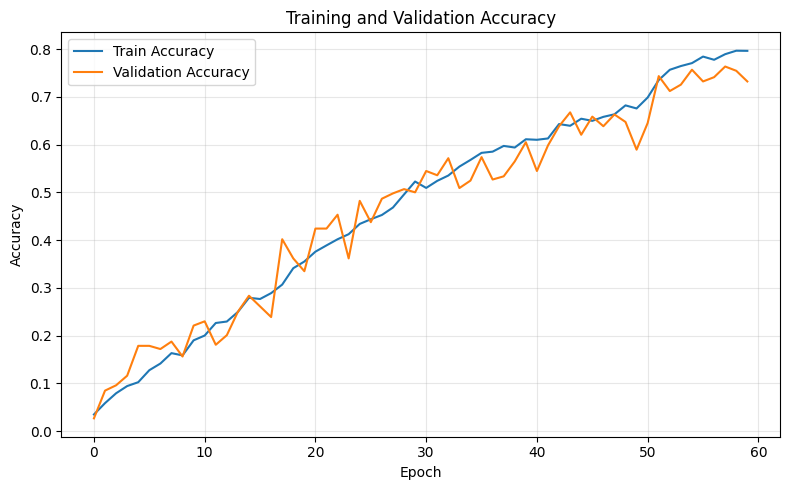

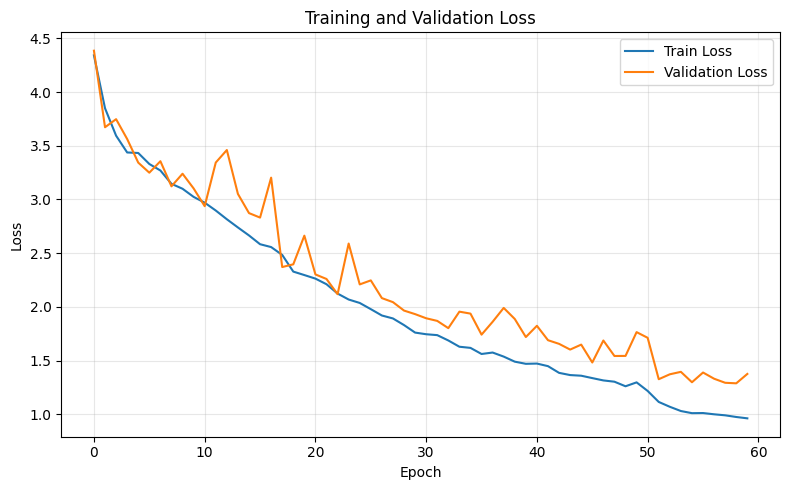

Loading best model: /content/deit_44c_no_download_results/best_deit_44c.keras


# Final Evaluation

224/224 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step


### Train Metrics

,split,loss,keras_accuracy,sklearn_accuracy,top3_accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1
0,train,0.920051,0.863205,0.863205,0.972362,0.877691,0.863205,0.862658,0.842391,0.908527,0.866258


### Train Classification Report

,precision,recall,f1-score,support
Astrocitoma T1,0.902439,0.787234,0.840909,141.000000
Astrocitoma T1C+,0.874172,0.713514,0.785714,185.000000
Astrocitoma T2,0.909091,0.583942,0.711111,137.000000
Carcinoma T1,0.910714,0.962264,0.935780,53.000000
Carcinoma T1C+,0.955556,0.955556,0.955556,90.000000
Carcinoma T2,0.857143,0.931034,0.892562,58.000000
Ependimoma T1,0.891892,0.916667,0.904110,36.000000
Ependimoma T1C+,0.734694,0.947368,0.827586,38.000000
Ependimoma T2,0.928571,0.847826,0.886364,46.000000
Ganglioglioma T1,0.941176,1.000000,0.969697,16.000000


## Train Confusion Matrix

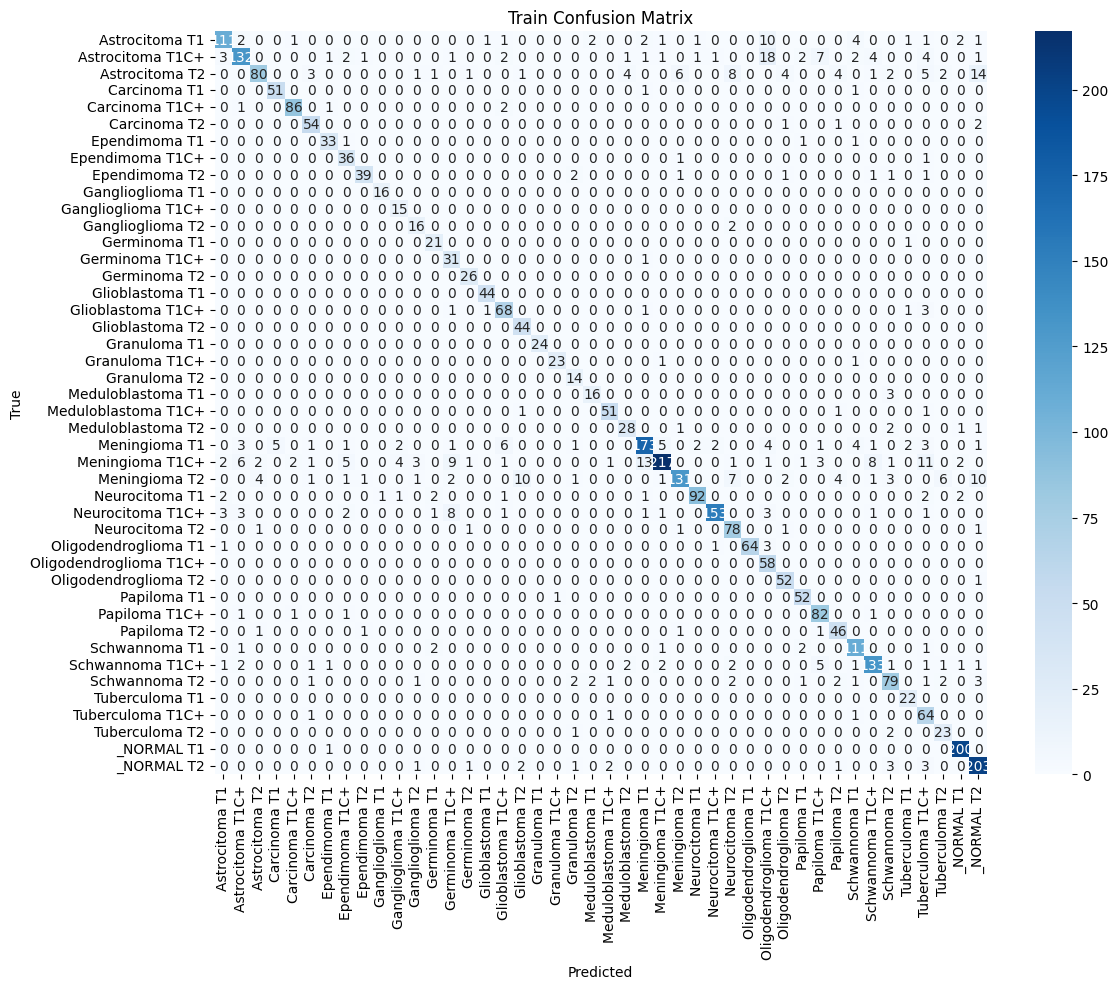

## Train ROC Curve

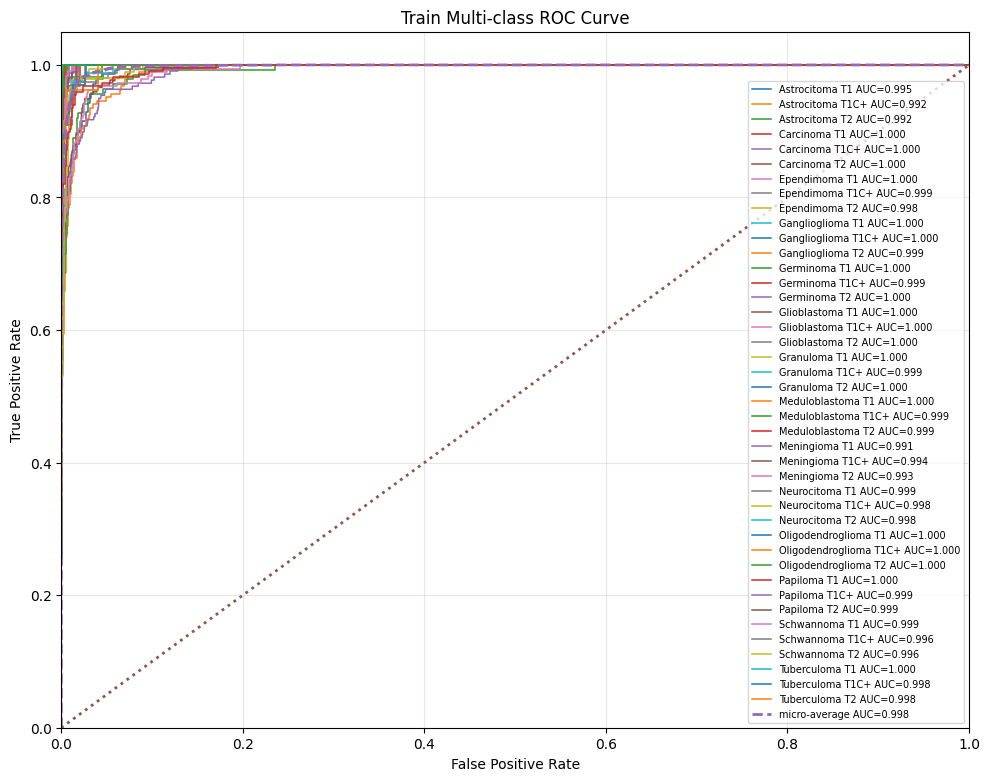

### Train ROC AUC Values

,class,auc
0,Astrocitoma T1,0.994687
1,Astrocitoma T1C+,0.991802
2,Astrocitoma T2,0.992271
3,Carcinoma T1,0.999749
4,Carcinoma T1C+,0.999513
5,Carcinoma T2,0.999658
6,Ependimoma T1,0.999788
7,Ependimoma T1C+,0.999079
8,Ependimoma T2,0.998119
9,Ganglioglioma T1,0.999982


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step


### Validation Metrics

,split,loss,keras_accuracy,sklearn_accuracy,top3_accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1
0,validation,1.293815,0.763393,0.763393,0.908482,0.785126,0.763393,0.757575,0.729938,0.78248,0.737575


### Validation Classification Report

,precision,recall,f1-score,support
Astrocitoma T1,0.846154,0.611111,0.709677,18.000000
Astrocitoma T1C+,0.937500,0.625000,0.750000,24.000000
Astrocitoma T2,0.500000,0.176471,0.260870,17.000000
Carcinoma T1,1.000000,0.857143,0.923077,7.000000
Carcinoma T1C+,0.833333,0.909091,0.869565,11.000000
Carcinoma T2,1.000000,0.857143,0.923077,7.000000
Ependimoma T1,0.800000,1.000000,0.888889,4.000000
Ependimoma T1C+,0.666667,0.800000,0.727273,5.000000
Ependimoma T2,0.750000,1.000000,0.857143,6.000000
Ganglioglioma T1,1.000000,1.000000,1.000000,2.000000


## Validation Confusion Matrix

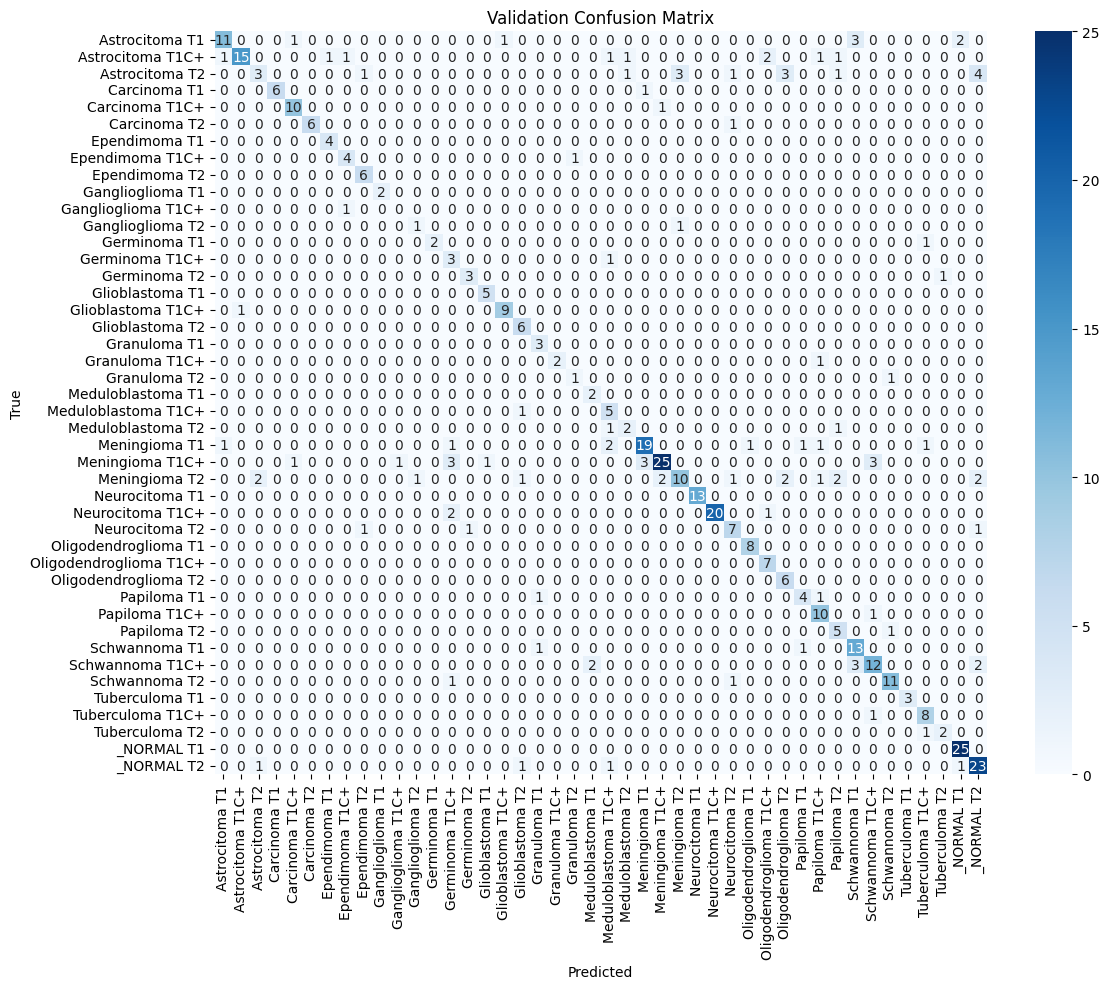

## Validation ROC Curve

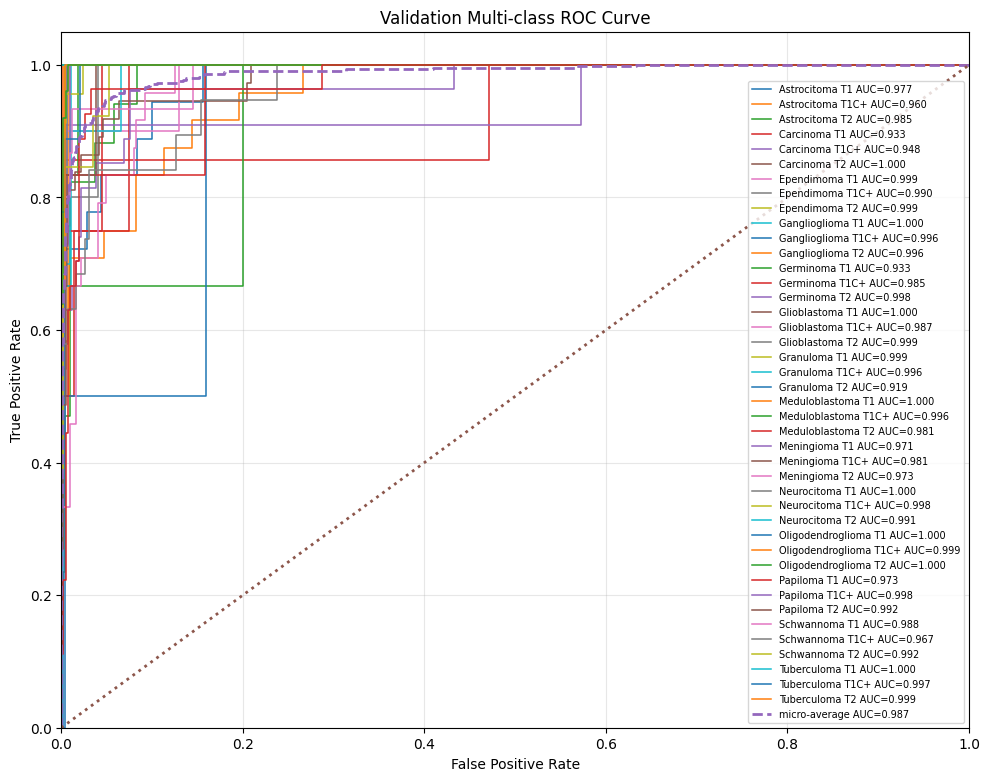

### Validation ROC AUC Values

,class,auc
0,Astrocitoma T1,0.976744
1,Astrocitoma T1C+,0.959709
2,Astrocitoma T2,0.984851
3,Carcinoma T1,0.932621
4,Carcinoma T1C+,0.947993
5,Carcinoma T2,1.000000
6,Ependimoma T1,0.998874
7,Ependimoma T1C+,0.990068
8,Ependimoma T2,0.998869
9,Ganglioglioma T1,1.000000


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step


### Test Metrics

,split,loss,keras_accuracy,sklearn_accuracy,top3_accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1
0,test,1.240223,0.787946,0.787946,0.917411,0.803691,0.787946,0.785229,0.75214,0.807395,0.762012


### Test Classification Report

,precision,recall,f1-score,support
Astrocitoma T1,0.733333,0.647059,0.687500,17.000000
Astrocitoma T1C+,0.894737,0.739130,0.809524,23.000000
Astrocitoma T2,0.833333,0.588235,0.689655,17.000000
Carcinoma T1,1.000000,1.000000,1.000000,6.000000
Carcinoma T1C+,0.909091,0.909091,0.909091,11.000000
Carcinoma T2,1.000000,0.750000,0.857143,8.000000
Ependimoma T1,0.500000,0.400000,0.444444,5.000000
Ependimoma T1C+,0.555556,1.000000,0.714286,5.000000
Ependimoma T2,0.800000,0.800000,0.800000,5.000000
Ganglioglioma T1,1.000000,1.000000,1.000000,2.000000


## Test Confusion Matrix

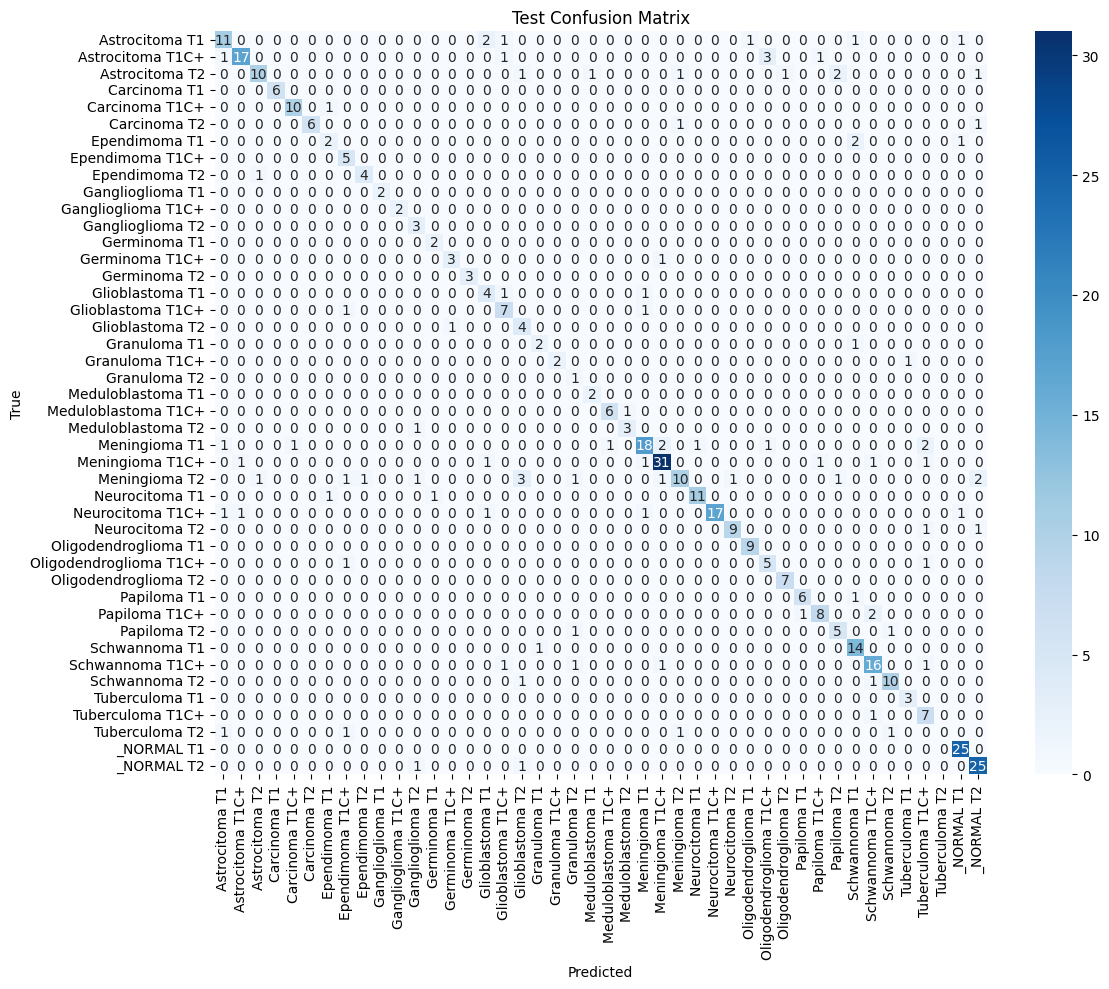

## Test ROC Curve

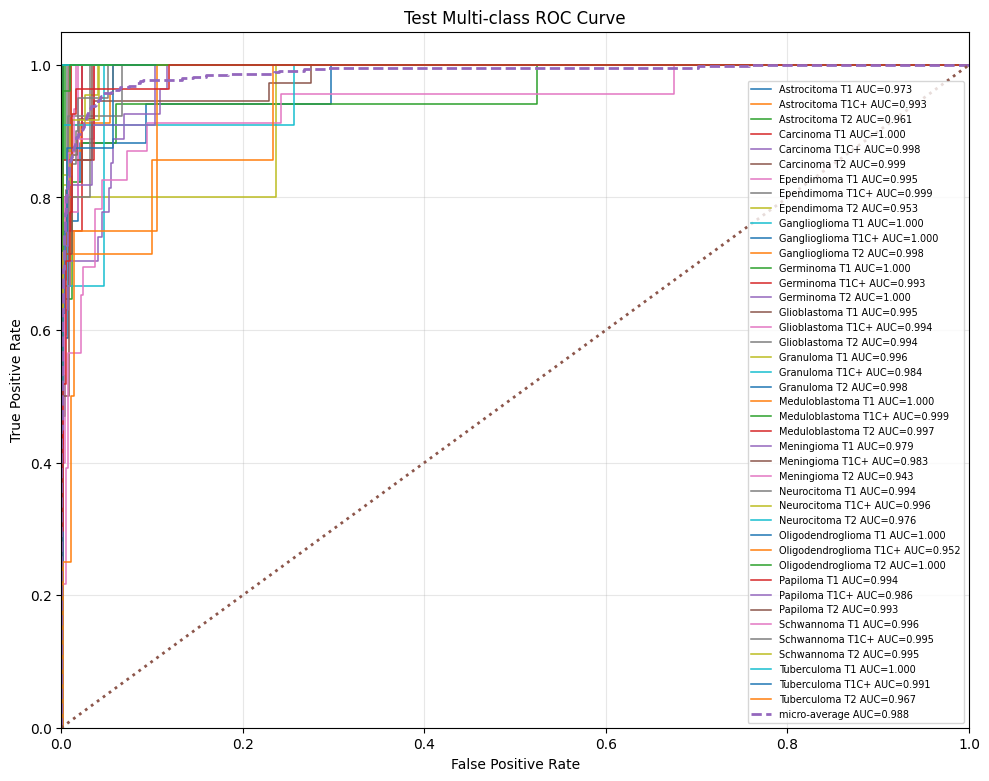

### Test ROC AUC Values

,class,auc
0,Astrocitoma T1,0.972977
1,Astrocitoma T1C+,0.992532
2,Astrocitoma T2,0.961103
3,Carcinoma T1,1.000000
4,Carcinoma T1C+,0.997920
5,Carcinoma T2,0.999432
6,Ependimoma T1,0.994582
7,Ependimoma T1C+,0.998646
8,Ependimoma T2,0.952596
9,Ganglioglioma T1,1.000000


### All Metrics Summary

,split,loss,keras_accuracy,sklearn_accuracy,top3_accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1
0,train,0.920051,0.863205,0.863205,0.972362,0.877691,0.863205,0.862658,0.842391,0.908527,0.866258
1,validation,1.293815,0.763393,0.763393,0.908482,0.785126,0.763393,0.757575,0.729938,0.782480,0.737575
2,test,1.240223,0.787946,0.787946,0.917411,0.803691,0.787946,0.785229,0.752140,0.807395,0.762012


## Completed

Results displayed inline and saved in: /content/deit_44c_no_download_results
Important files:
 - all_metrics_summary.csv
 - train/validation/test_classification_report.txt / .csv
 - train/validation/test_confusion_matrix.png
 - train/validation/test_roc_curve.png
 - train/validation/test_roc_auc.csv
 - accuracy_curve.png
 - loss_curve.png
 - best_deit_44c.keras


In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
DeiT full pipeline for Brain Tumor MRI 44c dataset WITHOUT dataset download.
Dataset expected to be already available locally.
Default dataset folder: /content/brain_tumor_mri_44c

Includes:
- Robust dataset-root detection
- Stratified train/validation/test split
- DeiT-style Vision Transformer classifier implemented in TensorFlow/Keras
- Stage 1: train classifier / transformer
- Inline Colab output: dataset summary, split table, train/val/test metrics,
  classification reports, confusion matrices, accuracy/loss curves,
  ROC curves and AUC values for train/validation/test
- Files also saved to output_dir

Colab run:
!python /content/deit_44c_no_download_full_metrics.py

Optional:
!python /content/deit_44c_no_download_full_metrics.py --data_dir /content/brain_tumor_mri_44c --epochs 60 --batch_size 16
"""

import os
import json
import argparse
import warnings
import shutil
from pathlib import Path

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger,
    TerminateOnNaN,
)

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from IPython.display import display, Markdown
    IN_NOTEBOOK = True
except Exception:
    IN_NOTEBOOK = False

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
BAD_DIR_NAMES = {"__MACOSX", ".ipynb_checkpoints"}


def md(text):
    if IN_NOTEBOOK:
        display(Markdown(text))
    else:
        print(text.replace("#", ""))


def show_df(title, df, max_rows=100):
    md(f"### {title}")
    if IN_NOTEBOOK:
        display(df.head(max_rows))
    else:
        print(df.head(max_rows).to_string(index=False))


def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)


def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)


def setup_gpu(disable_mixed_precision=True):
    gpus = tf.config.list_physical_devices("GPU")
    print("GPUs found:", gpus)
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception:
            pass

    if disable_mixed_precision:
        tf.keras.mixed_precision.set_global_policy("float32")
        print("Mixed precision disabled. Using float32 for stable training.")
    else:
        try:
            tf.keras.mixed_precision.set_global_policy("mixed_float16")
            print("Mixed precision enabled.")
        except Exception as e:
            print("Mixed precision not enabled:", e)


def count_images_inside(folder):
    folder = Path(folder)
    return sum(1 for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)


def debug_tree(data_dir, max_depth=5, max_items=160):
    print("\nDataset folder preview:")
    data_dir = Path(data_dir)
    shown = 0
    for root, dirs, files in os.walk(data_dir):
        dirs[:] = [d for d in dirs if d not in BAD_DIR_NAMES and not d.startswith(".")]
        depth = len(Path(root).relative_to(data_dir).parts)
        if depth > max_depth:
            dirs[:] = []
            continue
        indent = "  " * depth
        img_files = [f for f in files if Path(f).suffix.lower() in IMAGE_EXTENSIONS]
        print(f"{indent}{Path(root).name}/ dirs={len(dirs)} images_here={len(img_files)} total_images={count_images_inside(root)}")
        shown += 1
        if shown >= max_items:
            print("... preview truncated ...")
            break


def is_split_name(name):
    return name.lower().strip() in {"train", "training", "valid", "validation", "val", "test", "testing"}


def find_image_root(data_dir):
    data_dir = Path(data_dir)
    if not data_dir.exists():
        raise RuntimeError(f"Data directory does not exist: {data_dir}")

    candidates = []
    for root, dirs, files in os.walk(data_dir):
        rootp = Path(root)
        dirs[:] = [d for d in dirs if d not in BAD_DIR_NAMES and not d.startswith(".")]
        if len(rootp.relative_to(data_dir).parts) > 8:
            dirs[:] = []
            continue
        child_dirs = [rootp / d for d in dirs]
        if len(child_dirs) < 2:
            continue

        direct_class_dirs = []
        split_dirs = []
        total_child_images = 0
        for cd in child_dirs:
            n = count_images_inside(cd)
            total_child_images += n
            try:
                direct_here = sum(1 for p in cd.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
            except Exception:
                direct_here = 0
            if direct_here > 0:
                direct_class_dirs.append(cd)
            if is_split_name(cd.name) and n > 0:
                split_dirs.append(cd)

        if len(direct_class_dirs) >= 2:
            candidates.append((rootp, len(direct_class_dirs), total_child_images, "class_root"))

        if len(split_dirs) >= 1:
            split_class_count = 0
            for sd in split_dirs:
                for c in sd.iterdir():
                    if c.is_dir() and count_images_inside(c) > 0:
                        split_class_count += 1
            if split_class_count >= 2:
                candidates.append((rootp, split_class_count, total_child_images, "split_root"))

    if not candidates:
        debug_tree(data_dir)
        label_parents = {}
        for p in data_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
                label_parents.setdefault(str(p.parent), 0)
                label_parents[str(p.parent)] += 1
        if len(label_parents) >= 2:
            common = os.path.commonpath(list(label_parents.keys()))
            print(f"Fallback image root detected: {common}")
            return Path(common)
        raise RuntimeError(f"Could not detect class-folder image root inside {data_dir}. Check extraction structure above.")

    candidates = sorted(candidates, key=lambda x: (x[2], x[1]), reverse=True)
    root, nclasses, nimgs, mode = candidates[0]
    print(f"Detected image root: {root} | mode={mode} | class/split folders={nclasses} | images={nimgs}")
    return root


def make_dataframe(image_root):
    image_root = Path(image_root)
    records = []

    split_dirs = [d for d in image_root.iterdir() if d.is_dir() and is_split_name(d.name)]
    if split_dirs:
        for split_dir in split_dirs:
            split_name = split_dir.name.lower()
            if split_name in {"valid", "validation", "val"}:
                split_name = "val"
            elif split_name in {"train", "training"}:
                split_name = "train"
            elif split_name in {"test", "testing"}:
                split_name = "test"
            for class_dir in split_dir.iterdir():
                if not class_dir.is_dir():
                    continue
                for p in class_dir.rglob("*"):
                    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
                        records.append({"filepath": str(p), "label": class_dir.name, "given_split": split_name})
    else:
        for class_dir in image_root.iterdir():
            if not class_dir.is_dir() or class_dir.name.startswith("."):
                continue
            for p in class_dir.rglob("*"):
                if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
                    records.append({"filepath": str(p), "label": class_dir.name, "given_split": "none"})

    df = pd.DataFrame(records)
    if df.empty:
        debug_tree(image_root)
        raise RuntimeError(f"No images found under detected image root: {image_root}")

    before = len(df)
    df = df.drop_duplicates(subset=["filepath"]).reset_index(drop=True)

    class_counts = df["label"].value_counts().sort_index().reset_index()
    class_counts.columns = ["class", "count"]
    md("## Dataset Summary")
    print(f"Total images found: {len(df)} | duplicates removed: {before - len(df)}")
    print(f"Detected classes: {df['label'].nunique()}")
    show_df("Class Distribution", class_counts, max_rows=100)
    return df


def stratified_split(df, seed=42):
    if set(df["given_split"].unique()) & {"train", "val", "test"}:
        if {"train", "val", "test"}.issubset(set(df["given_split"].unique())):
            print("Using existing train/val/test split from dataset folders.")
            return df[df.given_split == "train"].copy(), df[df.given_split == "val"].copy(), df[df.given_split == "test"].copy()
        print("Partial split folders found; creating fresh stratified 80/10/10 split.")

    train_df, temp_df = train_test_split(
        df,
        test_size=0.20,
        stratify=df["label"],
        random_state=seed,
        shuffle=True,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df["label"],
        random_state=seed,
        shuffle=True,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def save_dataset_split_tables(train_df, val_df, test_df, out_dir):
    train_df.to_csv(Path(out_dir) / "train_split.csv", index=False)
    val_df.to_csv(Path(out_dir) / "validation_split.csv", index=False)
    test_df.to_csv(Path(out_dir) / "test_split.csv", index=False)

    all_labels = sorted(set(train_df.label) | set(val_df.label) | set(test_df.label))
    rows = []
    for label in all_labels:
        rows.append({
            "class": label,
            "train": int((train_df.label == label).sum()),
            "validation": int((val_df.label == label).sum()),
            "test": int((test_df.label == label).sum()),
            "total": int((train_df.label == label).sum() + (val_df.label == label).sum() + (test_df.label == label).sum()),
        })
    split_df = pd.DataFrame(rows)
    split_df.to_csv(Path(out_dir) / "dataset_split_distribution.csv", index=False)
    show_df("Train / Validation / Test Split Distribution", split_df, max_rows=100)


def deit_preprocess(x):
    # DeiT/ImageNet-style normalization: images from ImageDataGenerator are RGB 0..255.
    x = x / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    return (x - mean) / std


def build_generators(train_df, val_df, test_df, image_size, batch_size, seed):
    train_datagen = ImageDataGenerator(
        preprocessing_function=deit_preprocess,
        rotation_range=8,
        width_shift_range=0.04,
        height_shift_range=0.04,
        zoom_range=0.08,
        horizontal_flip=True,
        fill_mode="nearest",
    )
    eval_datagen = ImageDataGenerator(preprocessing_function=deit_preprocess)

    common = dict(
        x_col="filepath",
        y_col="label",
        target_size=(image_size, image_size),
        color_mode="rgb",
        class_mode="categorical",
        batch_size=batch_size,
        validate_filenames=True,
    )

    train_gen = train_datagen.flow_from_dataframe(train_df, shuffle=True, seed=seed, **common)
    train_eval_gen = eval_datagen.flow_from_dataframe(train_df, shuffle=False, **common)
    val_gen = eval_datagen.flow_from_dataframe(val_df, shuffle=False, **common)
    test_gen = eval_datagen.flow_from_dataframe(test_df, shuffle=False, **common)
    return train_gen, train_eval_gen, val_gen, test_gen


class PatchExtract(layers.Layer):
    def __init__(self, patch_size=16, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config


class PatchEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches + 1, output_dim=projection_dim)
        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, projection_dim),
            initializer="zeros",
            trainable=True,
        )

    def call(self, patches):
        batch_size = tf.shape(patches)[0]
        x = self.projection(patches)
        cls_tokens = tf.broadcast_to(self.cls_token, [batch_size, 1, self.projection_dim])
        x = tf.concat([cls_tokens, x], axis=1)
        positions = tf.range(start=0, limit=self.num_patches + 1, delta=1)
        x = x + self.position_embedding(positions)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches, "projection_dim": self.projection_dim})
        return config


class ClassToken(layers.Layer):
    def call(self, x):
        return x[:, 0]


def transformer_encoder(x, projection_dim, num_heads, mlp_dim, dropout):
    residual = x
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim // num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    x = layers.Add()([x, residual])

    residual = x
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(mlp_dim, activation=tf.nn.gelu)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(projection_dim)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Add()([x, residual])
    return x


def build_deit_model(
    num_classes,
    image_size=224,
    patch_size=16,
    projection_dim=192,
    transformer_layers=8,
    num_heads=3,
    mlp_dim=384,
    dropout=0.15,
    lr=3e-4,
    weight_decay=1e-4,
):
    num_patches = (image_size // patch_size) ** 2
    inputs = layers.Input(shape=(image_size, image_size, 3))

    patches = PatchExtract(patch_size, name="patch_extract")(inputs)
    x = PatchEmbedding(num_patches, projection_dim, name="patch_embedding")(patches)

    for _ in range(transformer_layers):
        x = transformer_encoder(x, projection_dim, num_heads, mlp_dim, dropout)

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = ClassToken(name="class_token")(x)
    x = layers.Dense(512, activation=tf.nn.gelu, kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation=tf.nn.gelu, kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout / 2)(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)

    model = models.Model(inputs, outputs, name="DeiT_Tiny_BrainTumor_44c")
    optimizer = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay, clipnorm=1.0)
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc")],
    )
    return model


def get_callbacks(out_dir, filename="best_deit_44c.keras", patience_es=12, patience_lr=5):
    return [
        ModelCheckpoint(filepath=str(Path(out_dir) / filename), monitor="val_accuracy", save_best_only=True, mode="max", verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=patience_lr, min_lr=1e-7, verbose=1),
        EarlyStopping(monitor="val_loss", patience=patience_es, restore_best_weights=True, verbose=1),
        TerminateOnNaN(),
        CSVLogger(str(Path(out_dir) / "training_log.csv"), append=True),
    ]


def plot_curves(history, out_dir, show_inline=True):
    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(Path(out_dir) / "history.csv", index=False)
    show_df("Epoch-wise Training History", hist_df, max_rows=200)

    md("## Training Curves")
    plt.figure(figsize=(8, 5))
    plt.plot(history.history.get("accuracy", []), label="Train Accuracy")
    plt.plot(history.history.get("val_accuracy", []), label="Validation Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(Path(out_dir) / "accuracy_curve.png", dpi=300)
    if show_inline:
        plt.show()
    else:
        plt.close()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history.get("loss", []), label="Train Loss")
    plt.plot(history.history.get("val_loss", []), label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(Path(out_dir) / "loss_curve.png", dpi=300)
    if show_inline:
        plt.show()
    else:
        plt.close()


def evaluate_and_save(model, gen, split_name, out_dir, class_names, show_inline=True):
    gen.reset()
    probs = model.predict(gen, verbose=1)
    y_true = gen.classes
    y_pred = np.argmax(probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    loss, keras_acc, top3 = model.evaluate(gen, verbose=0)

    metrics = {
        "split": split_name,
        "loss": float(loss),
        "keras_accuracy": float(keras_acc),
        "sklearn_accuracy": float(acc),
        "top3_accuracy": float(top3),
        "weighted_precision": float(precision),
        "weighted_recall": float(recall),
        "weighted_f1": float(f1),
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
    }
    metrics_df = pd.DataFrame([metrics])
    metrics_df.to_csv(Path(out_dir) / f"{split_name}_metrics.csv", index=False)
    show_df(f"{split_name.capitalize()} Metrics", metrics_df, max_rows=5)

    report_dict = classification_report(y_true, y_pred, target_names=class_names, zero_division=0, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()
    report_df.to_csv(Path(out_dir) / f"{split_name}_classification_report.csv")
    with open(Path(out_dir) / f"{split_name}_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(classification_report(y_true, y_pred, target_names=class_names, zero_division=0, digits=4))
    show_df(f"{split_name.capitalize()} Classification Report", report_df, max_rows=100)

    cm = confusion_matrix(y_true, y_pred)
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(Path(out_dir) / f"{split_name}_confusion_matrix.csv")

    md(f"## {split_name.capitalize()} Confusion Matrix")
    plt.figure(figsize=(12, 10))
    if sns is not None:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    else:
        plt.imshow(cm)
        plt.colorbar()
        plt.xticks(range(len(class_names)), class_names, rotation=90)
        plt.yticks(range(len(class_names)), class_names)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.title(f"{split_name.capitalize()} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(Path(out_dir) / f"{split_name}_confusion_matrix.png", dpi=300)
    if show_inline:
        plt.show()
    else:
        plt.close()

    np.save(Path(out_dir) / f"{split_name}_probabilities.npy", probs)
    np.save(Path(out_dir) / f"{split_name}_true_labels.npy", y_true)
    np.save(Path(out_dir) / f"{split_name}_pred_labels.npy", y_pred)
    return metrics, y_true, y_pred, probs


def plot_multiclass_roc(y_true, probs, class_names, out_dir, split_name="test", show_inline=True):
    n_classes = len(class_names)
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    roc_rows = []

    md(f"## {split_name.capitalize()} ROC Curve")
    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        if np.sum(y_bin[:, i]) == 0:
            continue
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], probs[:, i])
        auc_i = auc(fpr_i, tpr_i)
        roc_rows.append({"class": class_names[i], "auc": auc_i})
        plt.plot(fpr_i, tpr_i, lw=1.1, label=f"{class_names[i]} AUC={auc_i:.3f}")

    fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), probs.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    roc_rows.append({"class": "micro_average", "auc": auc_micro})
    plt.plot(fpr_micro, tpr_micro, linestyle="--", lw=2, label=f"micro-average AUC={auc_micro:.3f}")

    plt.plot([0, 1], [0, 1], linestyle=":", lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{split_name.capitalize()} Multi-class ROC Curve")
    plt.legend(loc="lower right", fontsize=7)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(Path(out_dir) / f"{split_name}_roc_curve.png", dpi=300)
    if show_inline:
        plt.show()
    else:
        plt.close()

    roc_df = pd.DataFrame(roc_rows)
    roc_df.to_csv(Path(out_dir) / f"{split_name}_roc_auc.csv", index=False)
    show_df(f"{split_name.capitalize()} ROC AUC Values", roc_df, max_rows=100)


def zip_results(out_dir):
    try:
        zip_path = shutil.make_archive(str(Path(out_dir)), "zip", out_dir)
        print("Backup ZIP saved:", zip_path)
    except Exception as e:
        print("ZIP creation skipped:", e)


def main(args):
    set_seed(args.seed)
    setup_gpu(disable_mixed_precision=not args.enable_mixed_precision)
    ensure_dir(args.output_dir)

    md("# DeiT Brain Tumor MRI 44c Training")
    print("Data directory:", args.data_dir)
    print("Output directory:", args.output_dir)
    print("Epochs:", args.epochs)

    print("Using already-downloaded dataset folder:", args.data_dir)
    image_root = find_image_root(args.data_dir)
    df = make_dataframe(image_root)

    train_df, val_df, test_df = stratified_split(df, seed=args.seed)
    print(f"Split sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
    save_dataset_split_tables(train_df, val_df, test_df, args.output_dir)

    train_gen, train_eval_gen, val_gen, test_gen = build_generators(
        train_df, val_df, test_df, args.image_size, args.batch_size, args.seed
    )
    class_indices = train_gen.class_indices
    class_names = [None] * len(class_indices)
    for name, idx in class_indices.items():
        class_names[idx] = name
    with open(Path(args.output_dir) / "class_indices.json", "w", encoding="utf-8") as f:
        json.dump(class_indices, f, indent=2)

    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(len(class_names)),
        y=train_gen.classes,
    )
    class_weight = {i: float(w) for i, w in enumerate(class_weights_array)}
    with open(Path(args.output_dir) / "class_weights.json", "w", encoding="utf-8") as f:
        json.dump(class_weight, f, indent=2)

    model = build_deit_model(
        num_classes=len(class_names),
        image_size=args.image_size,
        patch_size=args.patch_size,
        projection_dim=args.projection_dim,
        transformer_layers=args.transformer_layers,
        num_heads=args.num_heads,
        mlp_dim=args.mlp_dim,
        dropout=args.dropout,
        lr=args.lr,
        weight_decay=args.weight_decay,
    )
    model.summary()

    best_model_name = "best_deit_44c.keras"

    md("## Training DeiT Model")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=args.epochs,
        callbacks=get_callbacks(args.output_dir, best_model_name, patience_es=args.patience, patience_lr=args.lr_patience),
        class_weight=class_weight,
        verbose=1,
    )

    plot_curves(history, args.output_dir, show_inline=not args.no_inline)

    best_path = Path(args.output_dir) / best_model_name
    if best_path.exists():
        print(f"Loading best model: {best_path}")
        model = tf.keras.models.load_model(
            best_path,
            custom_objects={
                "PatchExtract": PatchExtract,
                "PatchEmbedding": PatchEmbedding,
                "ClassToken": ClassToken,
            },
        )

    md("# Final Evaluation")
    all_metrics = []
    for split_name, gen in [("train", train_eval_gen), ("validation", val_gen), ("test", test_gen)]:
        metrics, y_true, y_pred, probs = evaluate_and_save(
            model, gen, split_name, args.output_dir, class_names, show_inline=not args.no_inline
        )
        all_metrics.append(metrics)
        plot_multiclass_roc(y_true, probs, class_names, args.output_dir, split_name=split_name, show_inline=not args.no_inline)

    summary_df = pd.DataFrame(all_metrics)
    summary_df.to_csv(Path(args.output_dir) / "all_metrics_summary.csv", index=False)
    show_df("All Metrics Summary", summary_df, max_rows=10)

    model.save(Path(args.output_dir) / "final_deit_44c.keras")
    if args.make_zip:
        zip_results(args.output_dir)

    md("## Completed")
    print("Results displayed inline and saved in:", args.output_dir)
    print("Important files:")
    print(" - all_metrics_summary.csv")
    print(" - train/validation/test_classification_report.txt / .csv")
    print(" - train/validation/test_confusion_matrix.png")
    print(" - train/validation/test_roc_curve.png")
    print(" - train/validation/test_roc_auc.csv")
    print(" - accuracy_curve.png")
    print(" - loss_curve.png")
    print(" - best_deit_44c.keras")


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="DeiT pipeline for Brain Tumor MRI 44c without dataset download")
    parser.add_argument("--data_dir", type=str, default="/content/brain_tumor_mri_44c")
    parser.add_argument("--output_dir", type=str, default="/content/deit_44c_no_download_results")
    parser.add_argument("--image_size", type=int, default=224)
    parser.add_argument("--batch_size", type=int, default=16)
    parser.add_argument("--epochs", type=int, default=60)
    parser.add_argument("--patch_size", type=int, default=16)
    parser.add_argument("--projection_dim", type=int, default=192)
    parser.add_argument("--transformer_layers", type=int, default=8)
    parser.add_argument("--num_heads", type=int, default=3)
    parser.add_argument("--mlp_dim", type=int, default=384)
    parser.add_argument("--lr", type=float, default=3e-4)
    parser.add_argument("--weight_decay", type=float, default=1e-4)
    parser.add_argument("--dropout", type=float, default=0.15)
    parser.add_argument("--patience", type=int, default=15)
    parser.add_argument("--lr_patience", type=int, default=5)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--enable_mixed_precision", action="store_true", help="Enable mixed precision. Default is OFF for stability.")
    parser.add_argument("--no_inline", action="store_true", help="Disable inline plots/tables, only save files")
    parser.add_argument("--make_zip", action="store_true", help="Also create ZIP backup of result folder")

    args, unknown = parser.parse_known_args()
    if unknown:
        print("Ignoring unknown arguments:", unknown)
    main(args)


In [6]:
# ZIP + DOWNLOAD IN SINGLE CELL

!zip -r /content/deit_44c_no_download_results.zip /content/deit_44c_no_download_results

from google.colab import files
files.download('/content/deit_44c_no_download_results.zip')

  adding: content/deit_44c_no_download_results/ (stored 0%)
  adding: content/deit_44c_no_download_results/test_split.csv (deflated 80%)
  adding: content/deit_44c_no_download_results/best_deit_44c.keras (deflated 9%)
  adding: content/deit_44c_no_download_results/test_pred_labels.npy (deflated 81%)
  adding: content/deit_44c_no_download_results/test_roc_auc.csv (deflated 60%)
  adding: content/deit_44c_no_download_results/train_split.csv (deflated 82%)
  adding: content/deit_44c_no_download_results/validation_probabilities.npy (deflated 6%)
  adding: content/deit_44c_no_download_results/train_probabilities.npy (deflated 7%)
  adding: content/deit_44c_no_download_results/validation_confusion_matrix.csv (deflated 87%)
  adding: content/deit_44c_no_download_results/validation_confusion_matrix.png (deflated 25%)
  adding: content/deit_44c_no_download_results/class_indices.json (deflated 71%)
  adding: content/deit_44c_no_download_results/test_metrics.csv (deflated 44%)
  adding: content/d

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>